# BrainScanAI — Apprentissage semi-supervisé

## Objectif

Cette étape compare trois stratégies utilisant la même architecture CNN :

1. un modèle entraîné uniquement avec les labels faibles ;
2. un modèle semi-supervisé pré-entraîné avec les labels faibles puis
   affiné avec les labels experts ;
3. un modèle supervisé entraîné uniquement avec les labels experts.

Tous les modèles sont évalués sur le même jeu de test expert, constitué
d'images qui ne participent jamais à l'entraînement, à la validation,
au clustering ou à la génération des labels faibles.

## Hypothèse métier

L'erreur considérée comme la plus grave est le faux négatif :

- classe réelle : cancer ;
- prédiction : normal.

La métrique principale sera donc le rappel de la classe `cancer`,
complété par le F2-score, la précision, le F1-score macro, la balanced
accuracy, la ROC-AUC, la PR-AUC et la matrice de confusion.

Cette hypothèse devra être confirmée avec les partenaires médicaux.

## 1. Imports et configuration

In [1]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torchvision

from sklearn.model_selection import StratifiedShuffleSplit

In [2]:
RANDOM_STATE = 42


def fixer_aleatoire(seed: int) -> None:
    """
    Fixe les principales graines aléatoires utilisées dans le notebook.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


fixer_aleatoire(RANDOM_STATE)

print(f"PyTorch : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"Random state : {RANDOM_STATE}")

PyTorch : 2.13.0
Torchvision : 0.28.0
Random state : 42


## 2. Localisation des données

Les métadonnées de l'étape 2 permettent de retrouver :

- les 100 images disposant d'un label expert ;
- les 1 406 images initialement non annotées.

Les labels faibles produits lors de l'étape 3 sont chargés uniquement
pour audit.

Ils ne seront pas utilisés directement pour l'évaluation finale, car
leur interprétation a été réalisée à partir des 100 labels experts.

Une version sans fuite de données sera reconstruite après le verrouillage
du jeu de test.

In [3]:
def trouver_racine_projet(repertoire_depart: Path) -> Path:
    """
    Recherche la racine du projet contenant pyproject.toml.
    """

    for candidat in (
        repertoire_depart,
        *repertoire_depart.parents,
    ):
        if (candidat / "pyproject.toml").exists():
            return candidat

    raise FileNotFoundError(
        "Impossible de localiser la racine du projet."
    )


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = trouver_racine_projet(CURRENT_DIR)

FEATURES_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features"
    / "resnet50_imagenet1k_v2"
)

CLUSTERING_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "clustering"
)

SEMI_SUPERVISED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "semi_supervised"
)

SEMI_SUPERVISED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

METADATA_PATH = (
    FEATURES_DIR
    / "metadata.csv"
)

WEAK_LABELS_STEP3_PATH = (
    CLUSTERING_DIR
    / "weak_labels_unlabeled_only.csv"
)

STRONG_SPLIT_PATH = (
    SEMI_SUPERVISED_DIR
    / "strong_split_stratified.csv"
)

print(f"Racine du projet : {PROJECT_ROOT}")
print(f"Métadonnées : {METADATA_PATH}")
print(f"Labels faibles étape 3 : {WEAK_LABELS_STEP3_PATH}")
print(f"Sorties étape 4 : {SEMI_SUPERVISED_DIR}")
print()

print(f"Métadonnées présentes : {METADATA_PATH.exists()}")
print(
    "Labels faibles étape 3 présents :",
    WEAK_LABELS_STEP3_PATH.exists(),
)

Racine du projet : /Users/vincentdesmouceaux/dev/BrainScanAI
Métadonnées : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/features/resnet50_imagenet1k_v2/metadata.csv
Labels faibles étape 3 : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/clustering/weak_labels_unlabeled_only.csv
Sorties étape 4 : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised

Métadonnées présentes : True
Labels faibles étape 3 présents : True


In [4]:
df_metadata = pd.read_csv(
    METADATA_PATH
)

df_weak_step3 = pd.read_csv(
    WEAK_LABELS_STEP3_PATH
)

df_metadata["metadata_index"] = np.arange(
    len(df_metadata)
)

df_metadata["image_path"] = (
    df_metadata["chemin_relatif"]
    .apply(
        lambda chemin: str(
            PROJECT_ROOT / chemin
        )
    )
)

print(
    f"Nombre total d'images : "
    f"{len(df_metadata)}"
)

print(
    f"Labels faibles de l'étape 3 : "
    f"{len(df_weak_step3)}"
)

Nombre total d'images : 1506
Labels faibles de l'étape 3 : 1406


In [5]:
df_strong_all = (
    df_metadata[
        df_metadata["label"].notna()
    ]
    .reset_index(drop=True)
    .copy()
)

df_unlabeled_all = (
    df_metadata[
        df_metadata["label"].isna()
    ]
    .reset_index(drop=True)
    .copy()
)

df_strong_all["label_id"] = (
    df_strong_all["label_id"]
    .astype(int)
)

print(
    f"Images fortement labellisées : "
    f"{len(df_strong_all)}"
)

print(
    f"Images initialement non annotées : "
    f"{len(df_unlabeled_all)}"
)

display(
    df_strong_all[
        "label"
    ]
    .value_counts()
    .rename_axis("label")
    .reset_index(
        name="nombre_images"
    )
)

Images fortement labellisées : 100
Images initialement non annotées : 1406


,label,nombre_images
0,cancer,50
1,normal,50


In [6]:
assert len(df_metadata) == 1506
assert len(df_strong_all) == 100
assert len(df_unlabeled_all) == 1406
assert len(df_weak_step3) == 1406

assert not df_strong_all[
    "label"
].isna().any()

assert df_unlabeled_all[
    "label"
].isna().all()

assert df_metadata[
    "image_path"
].apply(
    lambda chemin: Path(chemin).exists()
).all()

chemins_strong = set(
    df_strong_all[
        "chemin_relatif"
    ]
)

chemins_unlabeled = set(
    df_unlabeled_all[
        "chemin_relatif"
    ]
)

assert chemins_strong.isdisjoint(
    chemins_unlabeled
)

assert (
    len(chemins_strong)
    + len(chemins_unlabeled)
    == 1506
)

print(
    "Validation réussie : données fortes et "
    "non annotées strictement séparées."
)

Validation réussie : données fortes et non annotées strictement séparées.


## 3. Création du split expert

Les 100 images fortement labellisées sont séparées en trois ensembles :

- entraînement : 64 images ;
- validation : 16 images ;
- test final : 20 images.

Chaque ensemble contient autant d'images `normal` que d'images `cancer`.

Le jeu de test final est verrouillé avant la génération des nouveaux
labels faibles.

Les labels et les features des images de test ne seront utilisés dans
aucune opération d'entraînement ou de sélection.

In [7]:
y_strong_all = (
    df_strong_all["label_id"]
    .to_numpy(dtype=int)
)

premier_split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=20,
    random_state=RANDOM_STATE,
)

indices_train_val, indices_test = next(
    premier_split.split(
        np.zeros(
            shape=(len(df_strong_all), 1)
        ),
        y_strong_all,
    )
)

y_train_val = y_strong_all[
    indices_train_val
]

deuxieme_split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=16,
    random_state=RANDOM_STATE,
)

indices_train_relatifs, indices_val_relatifs = next(
    deuxieme_split.split(
        np.zeros(
            shape=(len(indices_train_val), 1)
        ),
        y_train_val,
    )
)

indices_train = indices_train_val[
    indices_train_relatifs
]

indices_val = indices_train_val[
    indices_val_relatifs
]

print(f"Train : {len(indices_train)}")
print(f"Validation : {len(indices_val)}")
print(f"Test : {len(indices_test)}")

Train : 64
Validation : 16
Test : 20


In [8]:
df_strong_split = (
    df_strong_all.copy()
)

df_strong_split[
    "split"
] = "non_attribue"

df_strong_split.loc[
    indices_train,
    "split",
] = "train"

df_strong_split.loc[
    indices_val,
    "split",
] = "validation"

df_strong_split.loc[
    indices_test,
    "split",
] = "test"

assert not (
    df_strong_split["split"]
    == "non_attribue"
).any()

display(
    pd.crosstab(
        df_strong_split["split"],
        df_strong_split["label"],
        margins=True,
    )
)

label,cancer,normal,All
split,,,
test,10,10,20
train,32,32,64
validation,8,8,16
All,50,50,100


In [9]:
df_strong_train = (
    df_strong_split[
        df_strong_split["split"]
        == "train"
    ]
    .reset_index(drop=True)
    .copy()
)

df_strong_validation = (
    df_strong_split[
        df_strong_split["split"]
        == "validation"
    ]
    .reset_index(drop=True)
    .copy()
)

df_strong_test = (
    df_strong_split[
        df_strong_split["split"]
        == "test"
    ]
    .reset_index(drop=True)
    .copy()
)

print(
    f"Strong train : "
    f"{len(df_strong_train)}"
)

print(
    f"Strong validation : "
    f"{len(df_strong_validation)}"
)

print(
    f"Strong test : "
    f"{len(df_strong_test)}"
)

Strong train : 64
Strong validation : 16
Strong test : 20


In [10]:
chemins_train = set(
    df_strong_train[
        "chemin_relatif"
    ]
)

chemins_validation = set(
    df_strong_validation[
        "chemin_relatif"
    ]
)

chemins_test = set(
    df_strong_test[
        "chemin_relatif"
    ]
)

assert chemins_train.isdisjoint(
    chemins_validation
)

assert chemins_train.isdisjoint(
    chemins_test
)

assert chemins_validation.isdisjoint(
    chemins_test
)

assert len(chemins_train) == 64
assert len(chemins_validation) == 16
assert len(chemins_test) == 20

assert (
    len(chemins_train)
    + len(chemins_validation)
    + len(chemins_test)
    == 100
)

for dataframe in (
    df_strong_train,
    df_strong_validation,
    df_strong_test,
):
    repartition = (
        dataframe["label"]
        .value_counts()
        .to_dict()
    )

    assert (
        repartition["cancer"]
        == repartition["normal"]
    )

print(
    "Validation réussie : train, validation et test "
    "sont équilibrés et strictement disjoints."
)

Validation réussie : train, validation et test sont équilibrés et strictement disjoints.


In [11]:
colonnes_split = [
    "metadata_index",
    "chemin_relatif",
    "nom_fichier",
    "image_path",
    "label",
    "label_id",
    "split",
]

df_strong_split[
    colonnes_split
].to_csv(
    STRONG_SPLIT_PATH,
    index=False,
)

print(
    f"Split sauvegardé : "
    f"{STRONG_SPLIT_PATH}"
)

Split sauvegardé : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/strong_split_stratified.csv


In [12]:
df_strong_split_reload = pd.read_csv(
    STRONG_SPLIT_PATH
)

assert len(
    df_strong_split_reload
) == 100

assert (
    df_strong_split_reload[
        "split"
    ]
    .value_counts()
    .to_dict()
    == {
        "train": 64,
        "test": 20,
        "validation": 16,
    }
)

print(
    "Le split expert a été sauvegardé "
    "et rechargé avec succès."
)

Le split expert a été sauvegardé et rechargé avec succès.


## 4. Reconstruction des labels faibles sans fuite de données

Les labels faibles créés à l'étape 3 restent utiles pour l'analyse
exploratoire, mais ils ne sont pas utilisés directement ici.

Une nouvelle labellisation faible est reconstruite selon un protocole
strict :

1. la standardisation est ajustée uniquement sur les 1 406 images non
   annotées ;
2. la PCA est ajustée uniquement sur ces mêmes images ;
3. K-Means est entraîné uniquement sur ces images ;
4. les 64 images expertes du train servent uniquement à interpréter les
   identifiants des clusters ;
5. les images de validation et de test ne participent à aucune de ces
   opérations.

Les labels de validation et de test restent donc totalement inconnus
pendant la génération des labels faibles.

In [13]:
import joblib

from scipy.optimize import linear_sum_assignment

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

In [14]:
LAYER3_PATH = (
    FEATURES_DIR
    / "embeddings_layer3.npy"
)

AVGPOOL_PATH = (
    FEATURES_DIR
    / "embeddings_avgpool.npy"
)

WEAK_LABELS_LEAK_FREE_PATH = (
    SEMI_SUPERVISED_DIR
    / "weak_labels_leak_free.csv"
)

WEAK_LABELING_DIAGNOSTICS_PATH = (
    SEMI_SUPERVISED_DIR
    / "weak_labeling_diagnostics.csv"
)

WEAK_LABELING_PIPELINE_PATH = (
    SEMI_SUPERVISED_DIR
    / "weak_labeling_pipeline.joblib"
)

WEAK_LABELING_CONFIG_PATH = (
    SEMI_SUPERVISED_DIR
    / "weak_labeling_config.json"
)

## 5. Définition du périmètre du clustering

Le clustering est ajusté uniquement sur les 1 406 images sans annotation
experte.

Les 64 images du train expert sont transformées après l'entraînement du
clustering afin de déterminer la signification des clusters.

Les 16 images de validation et les 20 images de test sont totalement
exclues de ce processus.

In [15]:
indices_unlabeled = (
    df_unlabeled_all[
        "metadata_index"
    ]
    .to_numpy(dtype=int)
)

indices_strong_train = (
    df_strong_train[
        "metadata_index"
    ]
    .to_numpy(dtype=int)
)

indices_strong_validation = (
    df_strong_validation[
        "metadata_index"
    ]
    .to_numpy(dtype=int)
)

indices_strong_test = (
    df_strong_test[
        "metadata_index"
    ]
    .to_numpy(dtype=int)
)

print(
    f"Clustering — images non annotées : "
    f"{len(indices_unlabeled)}"
)

print(
    f"Mapping — train expert : "
    f"{len(indices_strong_train)}"
)

print(
    f"Validation exclue : "
    f"{len(indices_strong_validation)}"
)

print(
    f"Test exclu : "
    f"{len(indices_strong_test)}"
)

Clustering — images non annotées : 1406
Mapping — train expert : 64
Validation exclue : 16
Test exclu : 20


In [16]:
set_unlabeled = set(
    indices_unlabeled
)

set_train = set(
    indices_strong_train
)

set_validation = set(
    indices_strong_validation
)

set_test = set(
    indices_strong_test
)

assert set_unlabeled.isdisjoint(
    set_train
)

assert set_unlabeled.isdisjoint(
    set_validation
)

assert set_unlabeled.isdisjoint(
    set_test
)

assert set_train.isdisjoint(
    set_validation
)

assert set_train.isdisjoint(
    set_test
)

assert set_validation.isdisjoint(
    set_test
)

assert (
    len(set_unlabeled)
    + len(set_train)
    + len(set_validation)
    + len(set_test)
    == 1506
)

print(
    "Validation réussie : validation et test sont "
    "exclus de la génération des labels faibles."
)

Validation réussie : validation et test sont exclus de la génération des labels faibles.


17. Fonction de correspondance cluster-classe

Les identifiants des clusters sont arbitraires. Nous utiliserons les 64 labels experts du train pour décider si chaque cluster représente plutôt normal ou cancer.

In [17]:
def determiner_mapping_clusters(
    clusters_train: np.ndarray,
    y_train: np.ndarray,
) -> tuple[dict[int, int], pd.DataFrame]:
    """
    Détermine une correspondance bijective entre les clusters
    et les classes expertes à partir du train expert uniquement.
    """

    cluster_ids = np.sort(
        np.unique(clusters_train)
    )

    label_ids = np.sort(
        np.unique(y_train)
    )

    if len(cluster_ids) != 2:
        raise ValueError(
            "Les deux clusters ne sont pas représentés "
            "dans le train expert."
        )

    table_contingence = pd.crosstab(
        pd.Series(
            clusters_train,
            name="cluster_id",
        ),
        pd.Series(
            y_train,
            name="label_id",
        ),
    )

    table_contingence = (
        table_contingence.reindex(
            index=cluster_ids,
            columns=label_ids,
            fill_value=0,
        )
    )

    indices_clusters, indices_labels = (
        linear_sum_assignment(
            -table_contingence.to_numpy()
        )
    )

    mapping = {
        int(cluster_ids[index_cluster]): int(
            label_ids[index_label]
        )
        for index_cluster, index_label in zip(
            indices_clusters,
            indices_labels,
        )
    }

    return mapping, table_contingence

In [18]:
def convertir_clusters_en_labels(
    clusters: np.ndarray,
    mapping: dict[int, int],
) -> np.ndarray:
    """
    Convertit les identifiants des clusters en labels faibles.
    """

    return np.array(
        [
            mapping[int(cluster_id)]
            for cluster_id in clusters
        ],
        dtype=int,
    )

In [19]:
def construire_candidat_weak_labeling(
    X_complet: np.ndarray,
    representation: str,
) -> dict:
    """
    Construit une labellisation faible sans utiliser les données
    de validation ou de test.
    """

    X_unlabeled = X_complet[
        indices_unlabeled
    ]

    X_strong_train = X_complet[
        indices_strong_train
    ]

    y_strong_train = (
        df_strong_train[
            "label_id"
        ]
        .to_numpy(dtype=int)
    )

    # Ajustement uniquement sur les images non annotées.
    scaler = StandardScaler()

    X_unlabeled_standardise = (
        scaler.fit_transform(
            X_unlabeled
        )
        .astype(np.float32)
    )

    # PCA ajustée uniquement sur les images non annotées.
    pca = PCA(
        n_components=0.95,
        svd_solver="full",
    )

    X_unlabeled_pca = (
        pca.fit_transform(
            X_unlabeled_standardise
        )
        .astype(np.float32)
    )

    X_strong_train_standardise = (
        scaler.transform(
            X_strong_train
        )
        .astype(np.float32)
    )

    X_strong_train_pca = (
        pca.transform(
            X_strong_train_standardise
        )
        .astype(np.float32)
    )

    # K-Means ajusté uniquement sur les 1 406 images
    # initialement non annotées.
    kmeans = KMeans(
        n_clusters=2,
        n_init=50,
        random_state=RANDOM_STATE,
    )

    clusters_unlabeled = (
        kmeans.fit_predict(
            X_unlabeled_pca
        )
    )

    clusters_strong_train = (
        kmeans.predict(
            X_strong_train_pca
        )
    )

    mapping, table_contingence = (
        determiner_mapping_clusters(
            clusters_train=clusters_strong_train,
            y_train=y_strong_train,
        )
    )

    labels_train_interpretes = (
        convertir_clusters_en_labels(
            clusters=clusters_strong_train,
            mapping=mapping,
        )
    )

    weak_label_ids = (
        convertir_clusters_en_labels(
            clusters=clusters_unlabeled,
            mapping=mapping,
        )
    )

    ari_train = adjusted_rand_score(
        y_strong_train,
        clusters_strong_train,
    )

    accuracy_mapping_train = accuracy_score(
        y_strong_train,
        labels_train_interpretes,
    )

    silhouette_unlabeled = silhouette_score(
        X_unlabeled_pca,
        clusters_unlabeled,
    )

    # Distance aux deux centroïdes K-Means.
    distances_centroides = (
        kmeans.transform(
            X_unlabeled_pca
        )
    )

    lignes = np.arange(
        len(clusters_unlabeled)
    )

    distance_assignee = (
        distances_centroides[
            lignes,
            clusters_unlabeled,
        ]
    )

    distances_alternatives = (
        distances_centroides.copy()
    )

    distances_alternatives[
        lignes,
        clusters_unlabeled,
    ] = np.inf

    distance_alternative = (
        distances_alternatives.min(
            axis=1
        )
    )

    # Marge relative comprise entre 0 et 1.
    confidence_margin = (
        (
            distance_alternative
            - distance_assignee
        )
        / (
            distance_alternative
            + distance_assignee
            + 1e-12
        )
    )

    confidence_margin = np.clip(
        confidence_margin,
        0.0,
        1.0,
    )

    return {
        "representation": representation,
        "scaler": scaler,
        "pca": pca,
        "kmeans": kmeans,
        "mapping": mapping,
        "table_contingence": table_contingence,
        "clusters_unlabeled": clusters_unlabeled,
        "clusters_strong_train": clusters_strong_train,
        "weak_label_ids": weak_label_ids,
        "confidence_margin": confidence_margin,
        "ari_strong_train": float(
            ari_train
        ),
        "accuracy_mapping_train": float(
            accuracy_mapping_train
        ),
        "silhouette_unlabeled": float(
            silhouette_unlabeled
        ),
        "nombre_composantes_pca": int(
            X_unlabeled_pca.shape[1]
        ),
        "variance_conservee": float(
            pca.explained_variance_ratio_.sum()
        ),
    }

In [20]:
from pathlib import Path

import numpy as np


def trouver_racine_projet(repertoire_depart: Path) -> Path:
    """
    Recherche la racine du projet contenant pyproject.toml.
    """

    for candidat in (
        repertoire_depart,
        *repertoire_depart.parents,
    ):
        if (candidat / "pyproject.toml").exists():
            return candidat

    raise FileNotFoundError(
        "Impossible de localiser la racine du projet."
    )


PROJECT_ROOT = trouver_racine_projet(
    Path.cwd().resolve()
)

FEATURES_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features"
    / "resnet50_imagenet1k_v2"
)

LAYER3_PATH = (
    FEATURES_DIR
    / "embeddings_layer3.npy"
)

AVGPOOL_PATH = (
    FEATURES_DIR
    / "embeddings_avgpool.npy"
)

print(f"Layer3 présent : {LAYER3_PATH.exists()}")
print(f"Avgpool présent : {AVGPOOL_PATH.exists()}")

Layer3 présent : True
Avgpool présent : True


In [21]:
from pathlib import Path

import numpy as np


def trouver_racine_projet(repertoire_depart: Path) -> Path:
    """
    Recherche la racine du projet contenant pyproject.toml.
    """

    for candidat in (
        repertoire_depart,
        *repertoire_depart.parents,
    ):
        if (candidat / "pyproject.toml").exists():
            return candidat

    raise FileNotFoundError(
        "Impossible de trouver la racine du projet."
    )


# 1. Localisation du projet
PROJECT_ROOT = trouver_racine_projet(
    Path.cwd().resolve()
)

FEATURES_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features"
    / "resnet50_imagenet1k_v2"
)

LAYER3_PATH = (
    FEATURES_DIR
    / "embeddings_layer3.npy"
)

AVGPOOL_PATH = (
    FEATURES_DIR
    / "embeddings_avgpool.npy"
)

print(f"Racine du projet : {PROJECT_ROOT}")
print(f"Layer3 présent : {LAYER3_PATH.exists()}")
print(f"Avgpool présent : {AVGPOOL_PATH.exists()}")

assert LAYER3_PATH.exists(), (
    f"Fichier introuvable : {LAYER3_PATH}"
)

assert AVGPOOL_PATH.exists(), (
    f"Fichier introuvable : {AVGPOOL_PATH}"
)


# 2. Chargement des embeddings
X_layer3 = np.load(
    LAYER3_PATH
).astype(np.float32)

X_avgpool = np.load(
    AVGPOOL_PATH
).astype(np.float32)

print(f"X_layer3 chargé : {X_layer3.shape}")
print(f"X_avgpool chargé : {X_avgpool.shape}")

assert X_layer3.shape == (1506, 1024)
assert X_avgpool.shape == (1506, 2048)

assert np.isfinite(X_layer3).all()
assert np.isfinite(X_avgpool).all()


# 3. Vérification de la fonction nécessaire
assert "construire_candidat_weak_labeling" in globals(), (
    "La fonction construire_candidat_weak_labeling n'existe pas "
    "dans le kernel. Exécute d'abord la cellule qui la définit."
)


# 4. Construction des deux candidats
candidats_weak_labeling = {
    "layer3": construire_candidat_weak_labeling(
        X_complet=X_layer3,
        representation="layer3",
    ),
    "avgpool": construire_candidat_weak_labeling(
        X_complet=X_avgpool,
        representation="avgpool",
    ),
}

print(
    "Les deux candidats de labellisation faible "
    "ont été construits."
)

Racine du projet : /Users/vincentdesmouceaux/dev/BrainScanAI
Layer3 présent : True
Avgpool présent : True
X_layer3 chargé : (1506, 1024)
X_avgpool chargé : (1506, 2048)
Les deux candidats de labellisation faible ont été construits.


In [22]:
lignes_diagnostics = []

for nom, candidat in (
    candidats_weak_labeling.items()
):
    lignes_diagnostics.append(
        {
            "representation": nom,
            "dimensions_initiales": (
                X_layer3.shape[1]
                if nom == "layer3"
                else X_avgpool.shape[1]
            ),
            "composantes_pca": candidat[
                "nombre_composantes_pca"
            ],
            "variance_conservee": candidat[
                "variance_conservee"
            ],
            "ari_strong_train": candidat[
                "ari_strong_train"
            ],
            "accuracy_mapping_train": candidat[
                "accuracy_mapping_train"
            ],
            "silhouette_unlabeled": candidat[
                "silhouette_unlabeled"
            ],
            "mapping": json.dumps(
                {
                    str(cluster_id): int(
                        label_id
                    )
                    for cluster_id, label_id
                    in candidat[
                        "mapping"
                    ].items()
                },
                ensure_ascii=False,
            ),
        }
    )

df_weak_labeling_diagnostics = (
    pd.DataFrame(
        lignes_diagnostics
    )
    .sort_values(
        [
            "ari_strong_train",
            "silhouette_unlabeled",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(
    df_weak_labeling_diagnostics
)

,representation,dimensions_initiales,composantes_pca,variance_conservee,ari_strong_train,accuracy_mapping_train,silhouette_unlabeled,mapping
0,layer3,1024,317,0.950150,0.342934,0.796875,0.114198,"{""0"": 0, ""1"": 1}"
1,avgpool,2048,660,0.950011,0.108001,0.671875,0.139868,"{""0"": 1, ""1"": 0}"


1. ARI sur les 64 images expertes du train
2. score de silhouette sur les 1 406 images non annotées

In [23]:
REPRESENTATION_WEAK_RETENUE = str(
    df_weak_labeling_diagnostics
    .iloc[0][
        "representation"
    ]
)

candidat_retenu = (
    candidats_weak_labeling[
        REPRESENTATION_WEAK_RETENUE
    ]
)

print(
    "Représentation retenue :",
    REPRESENTATION_WEAK_RETENUE,
)

print(
    "ARI sur strong train :",
    round(
        candidat_retenu[
            "ari_strong_train"
        ],
        4,
    ),
)

print(
    "Accuracy de mapping sur strong train :",
    round(
        candidat_retenu[
            "accuracy_mapping_train"
        ],
        4,
    ),
)

print(
    "Silhouette sur les images non annotées :",
    round(
        candidat_retenu[
            "silhouette_unlabeled"
        ],
        4,
    ),
)

print(
    "Mapping cluster → classe :",
    candidat_retenu["mapping"],
)

Représentation retenue : layer3
ARI sur strong train : 0.3429
Accuracy de mapping sur strong train : 0.7969
Silhouette sur les images non annotées : 0.1142
Mapping cluster → classe : {0: 0, 1: 1}


In [24]:
label_id_to_name = (
    df_strong_train[
        [
            "label_id",
            "label",
        ]
    ]
    .drop_duplicates()
    .assign(
        label_id=lambda dataframe: (
            dataframe[
                "label_id"
            ].astype(int)
        )
    )
    .set_index(
        "label_id"
    )[
        "label"
    ]
    .to_dict()
)

table_contingence_retenue = (
    candidat_retenu[
        "table_contingence"
    ]
    .copy()
)

table_contingence_retenue.columns = [
    label_id_to_name[
        int(label_id)
    ]
    for label_id
    in table_contingence_retenue.columns
]

display(
    table_contingence_retenue
)

,normal,cancer
cluster_id,,
0,30,11
1,2,21


## 6. Création du jeu faiblement labellisé

Le tableau suivant contient exclusivement les 1 406 images sans label
expert.

Les labels faibles sont créés à partir :

- du cluster K-Means attribué ;
- de la correspondance déterminée avec les 64 labels experts du train.

La marge de confiance mesure la séparation relative entre le centroïde
attribué et le centroïde alternatif.

Cette marge n'est pas une probabilité médicale.

In [25]:
df_weak_leak_free = (
    df_unlabeled_all[
        [
            "metadata_index",
            "chemin_relatif",
            "nom_fichier",
            "image_path",
            "categorie",
        ]
    ]
    .reset_index(drop=True)
    .copy()
)

df_weak_leak_free[
    "cluster_id"
] = candidat_retenu[
    "clusters_unlabeled"
]

df_weak_leak_free[
    "weak_label_id"
] = candidat_retenu[
    "weak_label_ids"
]

df_weak_leak_free[
    "weak_label"
] = [
    label_id_to_name[
        int(label_id)
    ]
    for label_id in df_weak_leak_free[
        "weak_label_id"
    ]
]

df_weak_leak_free[
    "confidence_margin"
] = candidat_retenu[
    "confidence_margin"
]

df_weak_leak_free[
    "representation"
] = REPRESENTATION_WEAK_RETENUE

df_weak_leak_free[
    "algorithme"
] = "KMeans"

df_weak_leak_free[
    "label_source"
] = "weak_label_train_only_mapping"

display(
    df_weak_leak_free.head()
)

,metadata_index,chemin_relatif,nom_fichier,image_path,categorie,cluster_id,weak_label_id,weak_label,confidence_margin,representation,algorithme,label_source
0,100,data/raw/mri_dataset_brain_cancer_oc/sans_labe...,001b158a-7af8-451e-bf31-3a9116265f3a.jpg,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,sans_label,1,1,cancer,0.136752,layer3,KMeans,weak_label_train_only_mapping
1,101,data/raw/mri_dataset_brain_cancer_oc/sans_labe...,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,sans_label,0,0,normal,0.053016,layer3,KMeans,weak_label_train_only_mapping
2,102,data/raw/mri_dataset_brain_cancer_oc/sans_labe...,00455a62-f79f-4072-9a23-4951e759acdc.jpg,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,sans_label,0,0,normal,0.115506,layer3,KMeans,weak_label_train_only_mapping
3,103,data/raw/mri_dataset_brain_cancer_oc/sans_labe...,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,sans_label,0,0,normal,0.012053,layer3,KMeans,weak_label_train_only_mapping
4,104,data/raw/mri_dataset_brain_cancer_oc/sans_labe...,005d9a37-8894-4eb5-8367-1015d4a43638.jpg,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,sans_label,1,1,cancer,0.091460,layer3,KMeans,weak_label_train_only_mapping


In [26]:
assert len(
    df_weak_leak_free
) == 1406

assert set(
    df_weak_leak_free[
        "weak_label_id"
    ].unique()
).issubset(
    {0, 1}
)

assert df_weak_leak_free[
    "weak_label"
].notna().all()

assert np.isfinite(
    df_weak_leak_free[
        "confidence_margin"
    ]
).all()

assert df_weak_leak_free[
    "confidence_margin"
].between(
    0.0,
    1.0,
).all()

assert set(
    df_weak_leak_free[
        "metadata_index"
    ]
).isdisjoint(
    set_validation
)

assert set(
    df_weak_leak_free[
        "metadata_index"
    ]
).isdisjoint(
    set_test
)

assert set(
    df_weak_leak_free[
        "chemin_relatif"
    ]
).isdisjoint(
    chemins_train
)

assert set(
    df_weak_leak_free[
        "chemin_relatif"
    ]
).isdisjoint(
    chemins_validation
)

assert set(
    df_weak_leak_free[
        "chemin_relatif"
    ]
).isdisjoint(
    chemins_test
)

print(
    "Validation réussie : les 1 406 labels faibles "
    "ont été créés sans utiliser validation ou test."
)

Validation réussie : les 1 406 labels faibles ont été créés sans utiliser validation ou test.


In [27]:
quantiles_confiance = (
    df_weak_leak_free[
        "confidence_margin"
    ]
    .quantile(
        [
            0.00,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            1.00,
        ]
    )
    .to_frame(
        name="confidence_margin"
    )
    .rename_axis(
        "quantile"
    )
    .reset_index()
)

display(
    quantiles_confiance
)

,quantile,confidence_margin
0,0.00,0.000458
1,0.10,0.043033
2,0.25,0.075461
3,0.50,0.113326
4,0.75,0.145299
5,0.90,0.167513
6,1.00,0.224260


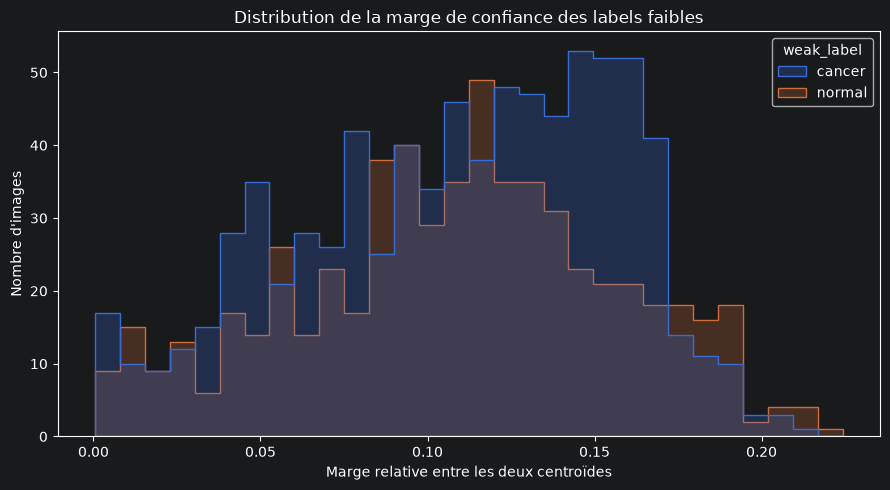

In [28]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_weak_leak_free,
    x="confidence_margin",
    hue="weak_label",
    bins=30,
    element="step",
)

plt.title(
    "Distribution de la marge de confiance "
    "des labels faibles"
)

plt.xlabel(
    "Marge relative entre les deux centroïdes"
)

plt.ylabel(
    "Nombre d'images"
)

plt.tight_layout()
plt.show()

In [29]:
df_weak_leak_free.to_csv(
    WEAK_LABELS_LEAK_FREE_PATH,
    index=False,
)

df_weak_labeling_diagnostics.to_csv(
    WEAK_LABELING_DIAGNOSTICS_PATH,
    index=False,
)

joblib.dump(
    {
        "representation": (
            REPRESENTATION_WEAK_RETENUE
        ),
        "scaler": candidat_retenu[
            "scaler"
        ],
        "pca": candidat_retenu[
            "pca"
        ],
        "kmeans": candidat_retenu[
            "kmeans"
        ],
        "mapping": candidat_retenu[
            "mapping"
        ],
    },
    WEAK_LABELING_PIPELINE_PATH,
)

configuration_weak_labeling = {
    "representation": (
        REPRESENTATION_WEAK_RETENUE
    ),
    "algorithme": "KMeans",
    "random_state": RANDOM_STATE,
    "nombre_clusters": 2,
    "nombre_images_clustering": int(
        len(df_unlabeled_all)
    ),
    "nombre_labels_mapping": int(
        len(df_strong_train)
    ),
    "nombre_validation_exclues": int(
        len(df_strong_validation)
    ),
    "nombre_test_exclus": int(
        len(df_strong_test)
    ),
    "ari_strong_train": float(
        candidat_retenu[
            "ari_strong_train"
        ]
    ),
    "accuracy_mapping_train": float(
        candidat_retenu[
            "accuracy_mapping_train"
        ]
    ),
    "silhouette_unlabeled": float(
        candidat_retenu[
            "silhouette_unlabeled"
        ]
    ),
    "mapping": {
        str(cluster_id): int(label_id)
        for cluster_id, label_id
        in candidat_retenu[
            "mapping"
        ].items()
    },
}

with WEAK_LABELING_CONFIG_PATH.open(
    "w",
    encoding="utf-8",
) as fichier:
    json.dump(
        configuration_weak_labeling,
        fichier,
        indent=2,
        ensure_ascii=False,
    )

print(
    f"Labels faibles : "
    f"{WEAK_LABELS_LEAK_FREE_PATH}"
)

print(
    f"Diagnostics : "
    f"{WEAK_LABELING_DIAGNOSTICS_PATH}"
)

print(
    f"Pipeline : "
    f"{WEAK_LABELING_PIPELINE_PATH}"
)

print(
    f"Configuration : "
    f"{WEAK_LABELING_CONFIG_PATH}"
)

Labels faibles : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/weak_labels_leak_free.csv
Diagnostics : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/weak_labeling_diagnostics.csv
Pipeline : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/weak_labeling_pipeline.joblib
Configuration : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/weak_labeling_config.json


In [30]:
print(
    "Fichier des labels faibles :",
    WEAK_LABELS_LEAK_FREE_PATH,
)

print(
    "Existe :",
    WEAK_LABELS_LEAK_FREE_PATH.exists(),
)

print(
    "Pipeline de clustering :",
    WEAK_LABELING_PIPELINE_PATH,
)

print(
    "Existe :",
    WEAK_LABELING_PIPELINE_PATH.exists(),
)

print(
    "Représentation retenue :",
    REPRESENTATION_WEAK_RETENUE,
)

Fichier des labels faibles : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/weak_labels_leak_free.csv
Existe : True
Pipeline de clustering : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/weak_labeling_pipeline.joblib
Existe : True
Représentation retenue : layer3


## 7. Préparation du CNN

Une architecture ResNet-18 pré-entraînée sur ImageNet est utilisée pour
les trois expériences.

La même architecture et la même initialisation seront conservées afin
que la comparaison porte uniquement sur la stratégie d'apprentissage :

- apprentissage faible ;
- apprentissage semi-supervisé ;
- apprentissage supervisé.

Pendant la première phase, seul le classifieur final est entraîné. Les
couches convolutives pré-entraînées restent gelées afin de limiter le
surapprentissage et l'impact des labels faibles bruités.

In [31]:
import copy

from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import (
    ResNet18_Weights,
    resnet18,
)
from torchvision.transforms import InterpolationMode

In [32]:
def selectionner_device() -> torch.device:
    """
    Sélectionne MPS, CUDA ou CPU selon le matériel disponible.
    """

    if (
        hasattr(torch.backends, "mps")
        and torch.backends.mps.is_available()
    ):
        return torch.device("mps")

    if torch.cuda.is_available():
        return torch.device("cuda")

    return torch.device("cpu")


DEVICE = selectionner_device()

print(f"Device utilisé : {DEVICE}")

Device utilisé : mps


## 8. Transformations des images

Le preprocessing reste compatible avec les poids ImageNet utilisés par
ResNet-18.

Les données d'entraînement reçoivent uniquement des augmentations
modérées :

- léger recadrage ;
- légère rotation ;
- faible translation ;
- faible variation d'échelle.

Les données de validation et de test ne reçoivent aucune augmentation
aléatoire.

In [33]:
WEIGHTS_RESNET18 = (
    ResNet18_Weights.IMAGENET1K_V1
)

PREPROCESS_RESNET18 = (
    WEIGHTS_RESNET18.transforms()
)

IMAGENET_MEAN = (
    PREPROCESS_RESNET18.mean
)

IMAGENET_STD = (
    PREPROCESS_RESNET18.std
)

print(f"Moyennes ImageNet : {IMAGENET_MEAN}")
print(f"Écarts-types ImageNet : {IMAGENET_STD}")
print(f"Crop final : {PREPROCESS_RESNET18.crop_size}")

Moyennes ImageNet : [0.485, 0.456, 0.406]
Écarts-types ImageNet : [0.229, 0.224, 0.225]
Crop final : [224]


In [34]:
train_transform = transforms.Compose(
    [
        transforms.Resize(
            256,
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.RandomResizedCrop(
            size=224,
            scale=(0.90, 1.00),
            ratio=(0.95, 1.05),
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.RandomRotation(
            degrees=5,
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.02, 0.02),
            scale=(0.98, 1.02),
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

evaluation_transform = (
    PREPROCESS_RESNET18
)

print("Transformations créées.")

Transformations créées.


## 9. Pondération des labels faibles

Tous les labels experts reçoivent un poids égal à 1.

Les labels faibles sont pondérés à partir de leur marge de confiance.
Cette pondération permet de diminuer l'influence des annotations les plus
incertaines sans supprimer automatiquement une grande partie du jeu de
données.

La formule utilisée est :

`sample_weight = 0.25 + 0.75 × confidence_margin`

Ce choix constitue une heuristique initiale qui sera documentée comme
une limite de l'expérience.

In [35]:
WEAK_WEIGHT_MIN = 0.25

df_weak_train = (
    df_weak_leak_free
    .reset_index(drop=True)
    .copy()
)

df_weak_train[
    "confidence_margin"
] = (
    df_weak_train[
        "confidence_margin"
    ]
    .astype(float)
    .clip(0.0, 1.0)
)

df_weak_train[
    "sample_weight"
] = (
    WEAK_WEIGHT_MIN
    + (
        1.0
        - WEAK_WEIGHT_MIN
    )
    * df_weak_train[
        "confidence_margin"
    ]
)

for dataframe in (
    df_strong_train,
    df_strong_validation,
    df_strong_test,
):
    dataframe[
        "sample_weight"
    ] = 1.0

    dataframe[
        "label_source"
    ] = "expert"

print(
    "Poids faible minimal :",
    round(
        df_weak_train[
            "sample_weight"
        ].min(),
        4,
    ),
)

print(
    "Poids faible moyen :",
    round(
        df_weak_train[
            "sample_weight"
        ].mean(),
        4,
    ),
)

print(
    "Poids faible maximal :",
    round(
        df_weak_train[
            "sample_weight"
        ].max(),
        4,
    ),
)

Poids faible minimal : 0.2503
Poids faible moyen : 0.3316
Poids faible maximal : 0.4182


In [36]:
colonnes_weak_requises = {
    "image_path",
    "weak_label_id",
    "weak_label",
    "sample_weight",
    "label_source",
}

colonnes_strong_requises = {
    "image_path",
    "label_id",
    "label",
    "sample_weight",
    "label_source",
}

assert colonnes_weak_requises.issubset(
    df_weak_train.columns
)

for dataframe in (
    df_strong_train,
    df_strong_validation,
    df_strong_test,
):
    assert colonnes_strong_requises.issubset(
        dataframe.columns
    )

assert len(df_weak_train) == 1406
assert len(df_strong_train) == 64
assert len(df_strong_validation) == 16
assert len(df_strong_test) == 20

print("DataFrames d'entraînement validés.")

DataFrames d'entraînement validés.


In [37]:
class BrainScanClassificationDataset(Dataset):
    """
    Dataset PyTorch pour la classification normal/cancer.
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        label_column: str,
        transform,
        source_name: str,
    ) -> None:
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.label_column = label_column
        self.transform = transform
        self.source_name = source_name

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(
        self,
        index: int,
    ) -> dict:
        ligne = self.dataframe.iloc[index]

        image_path = Path(
            ligne["image_path"]
        )

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image introuvable : {image_path}"
            )

        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image_tensor = self.transform(
                image
            )

        label = int(
            ligne[self.label_column]
        )

        sample_weight = float(
            ligne["sample_weight"]
        )

        return {
            "image": image_tensor,
            "label": torch.tensor(
                label,
                dtype=torch.long,
            ),
            "sample_weight": torch.tensor(
                sample_weight,
                dtype=torch.float32,
            ),
            "path": str(image_path),
            "source": self.source_name,
        }

In [38]:
weak_train_dataset = (
    BrainScanClassificationDataset(
        dataframe=df_weak_train,
        label_column="weak_label_id",
        transform=train_transform,
        source_name="weak",
    )
)

strong_train_dataset = (
    BrainScanClassificationDataset(
        dataframe=df_strong_train,
        label_column="label_id",
        transform=train_transform,
        source_name="strong_train",
    )
)

strong_validation_dataset = (
    BrainScanClassificationDataset(
        dataframe=df_strong_validation,
        label_column="label_id",
        transform=evaluation_transform,
        source_name="strong_validation",
    )
)

strong_test_dataset = (
    BrainScanClassificationDataset(
        dataframe=df_strong_test,
        label_column="label_id",
        transform=evaluation_transform,
        source_name="strong_test",
    )
)

print(
    f"Weak train : {len(weak_train_dataset)}"
)

print(
    f"Strong train : {len(strong_train_dataset)}"
)

print(
    "Strong validation :",
    len(strong_validation_dataset),
)

print(
    f"Strong test : {len(strong_test_dataset)}"
)

Weak train : 1406
Strong train : 64
Strong validation : 16
Strong test : 20


In [39]:
exemple_weak = weak_train_dataset[0]
exemple_strong = strong_train_dataset[0]

print("Exemple faible")
print(
    "Image :",
    tuple(
        exemple_weak["image"].shape
    ),
)
print(
    "Label :",
    exemple_weak["label"].item(),
)
print(
    "Poids :",
    round(
        exemple_weak[
            "sample_weight"
        ].item(),
        4,
    ),
)
print(
    "Source :",
    exemple_weak["source"],
)
print()

print("Exemple expert")
print(
    "Image :",
    tuple(
        exemple_strong["image"].shape
    ),
)
print(
    "Label :",
    exemple_strong["label"].item(),
)
print(
    "Poids :",
    exemple_strong[
        "sample_weight"
    ].item(),
)
print(
    "Source :",
    exemple_strong["source"],
)

Exemple faible
Image : (3, 224, 224)
Label : 1
Poids : 0.3526
Source : weak

Exemple expert
Image : (3, 224, 224)
Label : 1
Poids : 1.0
Source : strong_train


In [40]:
BATCH_SIZE_WEAK = 32
BATCH_SIZE_STRONG = 8
BATCH_SIZE_EVALUATION = 16
NUM_WORKERS = 0

data_loader_generator = (
    torch.Generator()
    .manual_seed(RANDOM_STATE)
)

weak_train_loader = DataLoader(
    weak_train_dataset,
    batch_size=BATCH_SIZE_WEAK,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    drop_last=False,
    generator=data_loader_generator,
)

strong_train_loader = DataLoader(
    strong_train_dataset,
    batch_size=BATCH_SIZE_STRONG,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    drop_last=False,
    generator=data_loader_generator,
)

strong_validation_loader = DataLoader(
    strong_validation_dataset,
    batch_size=BATCH_SIZE_EVALUATION,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    drop_last=False,
)

strong_test_loader = DataLoader(
    strong_test_dataset,
    batch_size=BATCH_SIZE_EVALUATION,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    drop_last=False,
)

print(
    "Batchs weak train :",
    len(weak_train_loader),
)

print(
    "Batchs strong train :",
    len(strong_train_loader),
)

print(
    "Batchs validation :",
    len(strong_validation_loader),
)

print(
    "Batchs test :",
    len(strong_test_loader),
)

Batchs weak train : 44
Batchs strong train : 8
Batchs validation : 1
Batchs test : 2


In [41]:
batch_weak = next(
    iter(weak_train_loader)
)

print(
    "Images :",
    tuple(
        batch_weak["image"].shape
    ),
)

print(
    "Labels :",
    tuple(
        batch_weak["label"].shape
    ),
)

print(
    "Poids :",
    tuple(
        batch_weak[
            "sample_weight"
        ].shape
    ),
)

print(
    "Labels présents :",
    torch.unique(
        batch_weak["label"]
    ).tolist(),
)

print(
    "Poids minimum du batch :",
    round(
        batch_weak[
            "sample_weight"
        ].min().item(),
        4,
    ),
)

print(
    "Poids maximum du batch :",
    round(
        batch_weak[
            "sample_weight"
        ].max().item(),
        4,
    ),
)

Images : (32, 3, 224, 224)
Labels : (32,)
Poids : (32,)
Labels présents : [0, 1]
Poids minimum du batch : 0.2653
Poids maximum du batch : 0.3975


In [42]:
LABEL_NAMES = {
    0: "normal",
    1: "cancer",
}


def denormaliser_image(
    image_tensor: torch.Tensor,
) -> np.ndarray:
    """
    Annule la normalisation ImageNet pour l'affichage.
    """

    mean = torch.tensor(
        IMAGENET_MEAN,
        dtype=image_tensor.dtype,
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD,
        dtype=image_tensor.dtype,
    ).view(3, 1, 1)

    image = (
        image_tensor.cpu()
        * std
        + mean
    )

    image = image.clamp(
        0.0,
        1.0,
    )

    return (
        image
        .permute(1, 2, 0)
        .numpy()
    )

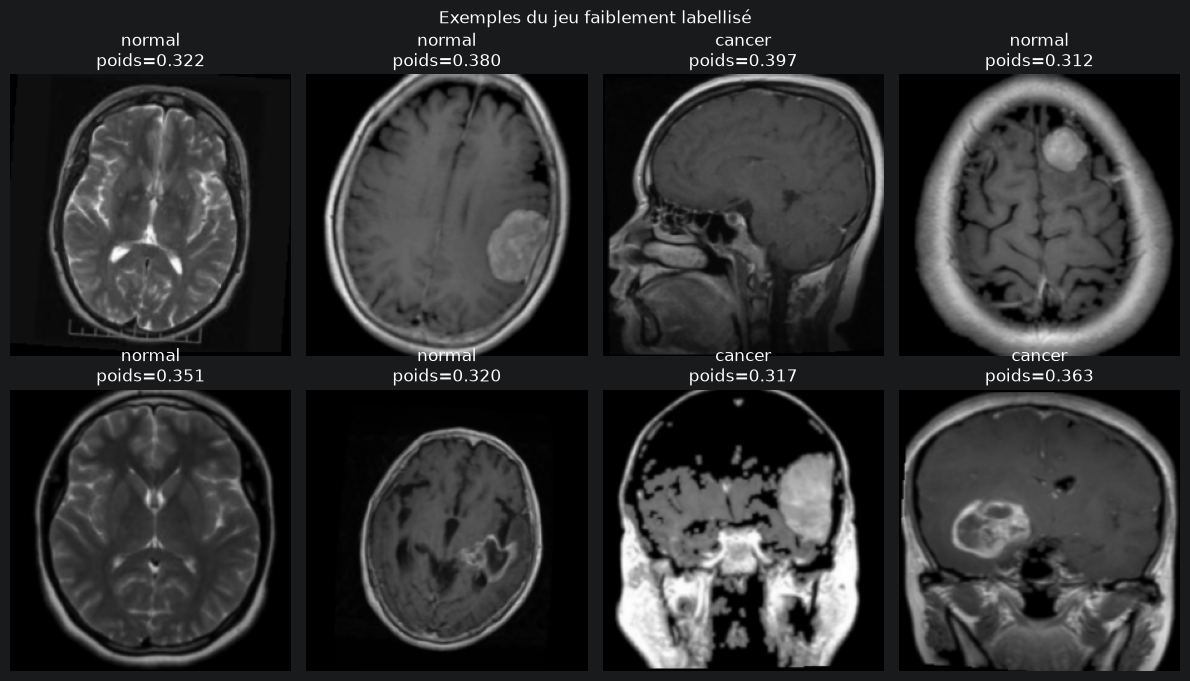

In [43]:
nombre_images_affichees = 8

figure, axes = plt.subplots(
    2,
    4,
    figsize=(12, 7),
)

for index, axe in enumerate(
    axes.flatten()
):
    image = denormaliser_image(
        batch_weak["image"][index]
    )

    label_id = int(
        batch_weak[
            "label"
        ][index].item()
    )

    poids = float(
        batch_weak[
            "sample_weight"
        ][index].item()
    )

    axe.imshow(image)
    axe.set_title(
        f"{LABEL_NAMES[label_id]}\n"
        f"poids={poids:.3f}"
    )
    axe.axis("off")

plt.suptitle(
    "Exemples du jeu faiblement labellisé"
)

plt.tight_layout()
plt.show()

## 10. Architecture commune aux expériences

ResNet-18 est initialisé avec les poids ImageNet.

La couche de classification ImageNet est remplacée par une couche
produisant deux logits :

- classe 0 : `normal` ;
- classe 1 : `cancer`.

Dans un premier temps, seul ce nouveau classifieur est entraînable.

In [44]:
def creer_resnet18_classification(
    nombre_classes: int = 2,
) -> nn.Module:
    """
    Crée un ResNet-18 pré-entraîné dont seul le classifieur
    final est initialement entraînable.
    """

    modele = resnet18(
        weights=WEIGHTS_RESNET18
    )

    for parameter in modele.parameters():
        parameter.requires_grad = False

    nombre_entrees = (
        modele.fc.in_features
    )

    modele.fc = nn.Linear(
        nombre_entrees,
        nombre_classes,
    )

    return modele

In [45]:
fixer_aleatoire(RANDOM_STATE)

modele_initial = (
    creer_resnet18_classification(
        nombre_classes=2
    )
)

etat_initial_resnet18 = copy.deepcopy(
    modele_initial.state_dict()
)

nombre_parametres_total = sum(
    parameter.numel()
    for parameter in modele_initial.parameters()
)

nombre_parametres_entrainables = sum(
    parameter.numel()
    for parameter in modele_initial.parameters()
    if parameter.requires_grad
)

print(
    f"Paramètres totaux : "
    f"{nombre_parametres_total:,}"
)

print(
    f"Paramètres entraînables : "
    f"{nombre_parametres_entrainables:,}"
)

print(
    "Part entraînable : "
    f"{100 * nombre_parametres_entrainables / nombre_parametres_total:.4f} %"
)

Paramètres totaux : 11,177,538
Paramètres entraînables : 1,026
Part entraînable : 0.0092 %


In [46]:
modele_test = (
    creer_resnet18_classification()
)

modele_test.load_state_dict(
    etat_initial_resnet18
)

modele_test = modele_test.to(
    DEVICE
)

images_test = (
    batch_weak["image"][:4]
    .to(DEVICE)
)

with torch.inference_mode():
    logits_test = modele_test(
        images_test
    )

print(
    f"Entrée : "
    f"{tuple(images_test.shape)}"
)

print(
    f"Sortie : "
    f"{tuple(logits_test.shape)}"
)

print(
    "Paramètres entraînables :",
    sum(
        parameter.numel()
        for parameter
        in modele_test.parameters()
        if parameter.requires_grad
    ),
)

Entrée : (4, 3, 224, 224)
Sortie : (4, 2)
Paramètres entraînables : 1026


## 11. Métriques et fonctions d'entraînement

La classe positive est la classe `cancer`, encodée par la valeur `1`.

Les métriques principales sont :

- rappel de la classe cancer ;
- F2-score de la classe cancer ;
- F1-score macro ;
- balanced accuracy ;
- précision de la classe cancer ;
- ROC-AUC ;
- Average Precision, utilisée comme synthèse de la courbe
  précision-rappel.

Le meilleur checkpoint est sélectionné à partir du F2-score calculé sur
le jeu expert de validation.

Le jeu de test final reste fermé pendant cette sélection.

In [47]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

In [48]:
def calculer_metriques_classification(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_probability_cancer: np.ndarray,
) -> dict:
    """
    Calcule les métriques de classification binaire.

    La classe cancer est la classe positive, encodée par 1.
    """

    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=int,
    )

    y_probability_cancer = np.asarray(
        y_probability_cancer,
        dtype=float,
    )

    metriques = {
        "accuracy": float(
            accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "precision_cancer": float(
            precision_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0,
            )
        ),
        "recall_cancer": float(
            recall_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0,
            )
        ),
        "f1_cancer": float(
            f1_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0,
            )
        ),
        "f2_cancer": float(
            fbeta_score(
                y_true,
                y_pred,
                beta=2,
                pos_label=1,
                zero_division=0,
            )
        ),
        "f1_macro": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                y_true,
                y_probability_cancer,
            )
        ),
        "average_precision": float(
            average_precision_score(
                y_true,
                y_probability_cancer,
            )
        ),
    }

    return metriques

## 12. Pondération des classes

Les poids de classes compensent une éventuelle différence d'effectif
entre les labels faibles `normal` et `cancer`.

Ils sont calculés uniquement à partir du jeu d'entraînement concerné.

La perte finale combine :

- le poids de la classe ;
- le poids individuel dérivé de la confiance du label faible.

In [49]:
def calculer_poids_classes(
    labels: np.ndarray,
    nombre_classes: int = 2,
) -> torch.Tensor:
    """
    Calcule des poids inversement proportionnels
    aux effectifs de chaque classe.
    """

    labels = np.asarray(
        labels,
        dtype=int,
    )

    effectifs = np.bincount(
        labels,
        minlength=nombre_classes,
    )

    if np.any(effectifs == 0):
        raise ValueError(
            "Chaque classe doit être présente dans "
            "le jeu d'entraînement."
        )

    nombre_total = len(labels)

    poids = (
        nombre_total
        / (
            nombre_classes
            * effectifs
        )
    )

    return torch.tensor(
        poids,
        dtype=torch.float32,
    )

In [50]:
poids_classes_weak = calculer_poids_classes(
    df_weak_train[
        "weak_label_id"
    ].to_numpy(dtype=int)
)

print(
    "Effectifs des labels faibles :"
)

display(
    df_weak_train[
        "weak_label"
    ]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="nombre_images")
)

print(
    "Poids des classes :",
    poids_classes_weak.tolist(),
)

Effectifs des labels faibles :


,label,nombre_images
0,cancer,805
1,normal,601


Poids des classes : [1.1697171926498413, 0.8732919096946716]


In [51]:
def calculer_perte_ponderee(
    logits: torch.Tensor,
    labels: torch.Tensor,
    sample_weights: torch.Tensor,
    criterion: nn.Module,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Calcule une Cross-Entropy pondérée par observation.

    Retourne :
    - la perte moyenne pondérée ;
    - les pertes individuelles avant pondération.
    """

    pertes_individuelles = criterion(
        logits,
        labels,
    )

    poids_total = sample_weights.sum().clamp_min(
        1e-12
    )

    perte_ponderee = (
        pertes_individuelles
        * sample_weights
    ).sum() / poids_total

    return (
        perte_ponderee,
        pertes_individuelles,
    )

In [52]:
def entrainer_une_epoque(
    modele: nn.Module,
    data_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    """
    Entraîne le modèle pendant une époque.

    Retourne la perte moyenne pondérée.
    """

    modele.train()

    somme_pertes_ponderees = 0.0
    somme_poids = 0.0

    for batch in data_loader:
        images = batch[
            "image"
        ].to(
            device,
            non_blocking=device.type == "cuda",
        )

        labels = batch[
            "label"
        ].to(
            device,
            non_blocking=device.type == "cuda",
        )

        sample_weights = batch[
            "sample_weight"
        ].to(
            device,
            non_blocking=device.type == "cuda",
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = modele(images)

        perte, pertes_individuelles = (
            calculer_perte_ponderee(
                logits=logits,
                labels=labels,
                sample_weights=sample_weights,
                criterion=criterion,
            )
        )

        perte.backward()
        optimizer.step()

        somme_pertes_ponderees += float(
            (
                pertes_individuelles.detach()
                * sample_weights.detach()
            )
            .sum()
            .cpu()
            .item()
        )

        somme_poids += float(
            sample_weights.detach()
            .sum()
            .cpu()
            .item()
        )

    return (
        somme_pertes_ponderees
        / max(somme_poids, 1e-12)
    )

In [53]:
def evaluer_modele(
    modele: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[dict, dict]:
    """
    Évalue le modèle sans modifier ses paramètres.

    Retourne :
    - les métriques ;
    - les prédictions détaillées.
    """

    modele.eval()

    somme_pertes_ponderees = 0.0
    somme_poids = 0.0

    tous_labels = []
    toutes_predictions = []
    toutes_probabilites = []
    tous_chemins = []

    with torch.inference_mode():
        for batch in data_loader:
            images = batch[
                "image"
            ].to(
                device,
                non_blocking=device.type == "cuda",
            )

            labels = batch[
                "label"
            ].to(
                device,
                non_blocking=device.type == "cuda",
            )

            sample_weights = batch[
                "sample_weight"
            ].to(
                device,
                non_blocking=device.type == "cuda",
            )

            logits = modele(images)

            _, pertes_individuelles = (
                calculer_perte_ponderee(
                    logits=logits,
                    labels=labels,
                    sample_weights=sample_weights,
                    criterion=criterion,
                )
            )

            probabilites = torch.softmax(
                logits,
                dim=1,
            )

            probabilites_cancer = (
                probabilites[:, 1]
            )

            predictions = torch.argmax(
                logits,
                dim=1,
            )

            somme_pertes_ponderees += float(
                (
                    pertes_individuelles
                    * sample_weights
                )
                .sum()
                .cpu()
                .item()
            )

            somme_poids += float(
                sample_weights
                .sum()
                .cpu()
                .item()
            )

            tous_labels.extend(
                labels.cpu().numpy().tolist()
            )

            toutes_predictions.extend(
                predictions.cpu().numpy().tolist()
            )

            toutes_probabilites.extend(
                probabilites_cancer
                .cpu()
                .numpy()
                .tolist()
            )

            tous_chemins.extend(
                batch["path"]
            )

    y_true = np.asarray(
        tous_labels,
        dtype=int,
    )

    y_pred = np.asarray(
        toutes_predictions,
        dtype=int,
    )

    y_probability_cancer = np.asarray(
        toutes_probabilites,
        dtype=float,
    )

    metriques = (
        calculer_metriques_classification(
            y_true=y_true,
            y_pred=y_pred,
            y_probability_cancer=(
                y_probability_cancer
            ),
        )
    )

    metriques["loss"] = float(
        somme_pertes_ponderees
        / max(somme_poids, 1e-12)
    )

    details = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_probability_cancer": (
            y_probability_cancer
        ),
        "paths": tous_chemins,
    }

    return metriques, details

In [54]:
def copier_state_dict_cpu(
    modele: nn.Module,
) -> dict:
    """
    Copie les paramètres du modèle vers le CPU.

    Cela permet de sauvegarder un checkpoint portable.
    """

    return {
        nom: tenseur.detach().cpu().clone()
        for nom, tenseur
        in modele.state_dict().items()
    }

In [55]:
def entrainer_modele(
    modele: nn.Module,
    train_loader: DataLoader,
    validation_loader: DataLoader,
    poids_classes: torch.Tensor,
    device: torch.device,
    nombre_epoques: int,
    learning_rate: float,
    patience: int,
    nom_experience: str,
) -> tuple[nn.Module, pd.DataFrame, dict]:
    """
    Entraîne un modèle avec early stopping.

    Le meilleur modèle est sélectionné selon le F2-score
    de la classe cancer sur la validation experte.
    """

    modele = modele.to(device)

    poids_classes_device = (
        poids_classes.to(device)
    )

    criterion = nn.CrossEntropyLoss(
        weight=poids_classes_device,
        reduction="none",
    )

    parametres_entrainables = [
        parameter
        for parameter in modele.parameters()
        if parameter.requires_grad
    ]

    optimizer = torch.optim.AdamW(
        parametres_entrainables,
        lr=learning_rate,
        weight_decay=1e-4,
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        )
    )

    historique = []

    meilleur_f2 = -np.inf
    meilleure_epoque = 0
    meilleur_etat = None
    meilleur_resultat_validation = None

    nombre_epoques_sans_amelioration = 0

    for epoque in range(
        1,
        nombre_epoques + 1,
    ):
        train_loss = entrainer_une_epoque(
            modele=modele,
            data_loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
        )

        metriques_validation, _ = (
            evaluer_modele(
                modele=modele,
                data_loader=validation_loader,
                criterion=criterion,
                device=device,
            )
        )

        f2_validation = (
            metriques_validation[
                "f2_cancer"
            ]
        )

        scheduler.step(
            f2_validation
        )

        learning_rate_actuel = float(
            optimizer.param_groups[0]["lr"]
        )

        ligne_historique = {
            "experience": nom_experience,
            "epoque": epoque,
            "learning_rate": (
                learning_rate_actuel
            ),
            "train_loss": train_loss,
            "validation_loss": (
                metriques_validation["loss"]
            ),
            "validation_accuracy": (
                metriques_validation[
                    "accuracy"
                ]
            ),
            "validation_balanced_accuracy": (
                metriques_validation[
                    "balanced_accuracy"
                ]
            ),
            "validation_precision_cancer": (
                metriques_validation[
                    "precision_cancer"
                ]
            ),
            "validation_recall_cancer": (
                metriques_validation[
                    "recall_cancer"
                ]
            ),
            "validation_f1_cancer": (
                metriques_validation[
                    "f1_cancer"
                ]
            ),
            "validation_f2_cancer": (
                metriques_validation[
                    "f2_cancer"
                ]
            ),
            "validation_f1_macro": (
                metriques_validation[
                    "f1_macro"
                ]
            ),
            "validation_roc_auc": (
                metriques_validation[
                    "roc_auc"
                ]
            ),
            "validation_average_precision": (
                metriques_validation[
                    "average_precision"
                ]
            ),
        }

        historique.append(
            ligne_historique
        )

        print(
            f"[{nom_experience}] "
            f"Époque {epoque:02d}/{nombre_epoques} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss="
            f"{metriques_validation['loss']:.4f} | "
            f"recall_cancer="
            f"{metriques_validation['recall_cancer']:.4f} | "
            f"F2="
            f"{metriques_validation['f2_cancer']:.4f} | "
            f"F1_macro="
            f"{metriques_validation['f1_macro']:.4f}"
        )

        if f2_validation > meilleur_f2 + 1e-8:
            meilleur_f2 = f2_validation
            meilleure_epoque = epoque

            meilleur_etat = (
                copier_state_dict_cpu(
                    modele
                )
            )

            meilleur_resultat_validation = (
                metriques_validation.copy()
            )

            nombre_epoques_sans_amelioration = 0

        else:
            nombre_epoques_sans_amelioration += 1

        if (
            nombre_epoques_sans_amelioration
            >= patience
        ):
            print(
                "Early stopping : aucune amélioration "
                f"du F2 pendant {patience} époques."
            )
            break

    if meilleur_etat is None:
        raise RuntimeError(
            "Aucun checkpoint valide n'a été produit."
        )

    modele.load_state_dict(
        meilleur_etat
    )

    dataframe_historique = pd.DataFrame(
        historique
    )

    resume = {
        "experience": nom_experience,
        "meilleure_epoque": int(
            meilleure_epoque
        ),
        "meilleur_f2_validation": float(
            meilleur_f2
        ),
        "metriques_validation": (
            meilleur_resultat_validation
        ),
        "state_dict": meilleur_etat,
    }

    return (
        modele,
        dataframe_historique,
        resume,
    )

In [56]:
MODELS_DIR = (
    SEMI_SUPERVISED_DIR
    / "models"
)

HISTORY_DIR = (
    SEMI_SUPERVISED_DIR
    / "histories"
)

PREDICTIONS_DIR = (
    SEMI_SUPERVISED_DIR
    / "predictions"
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

HISTORY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PREDICTIONS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

WEAK_ONLY_CHECKPOINT_PATH = (
    MODELS_DIR
    / "resnet18_weak_only.pt"
)

WEAK_ONLY_HISTORY_PATH = (
    HISTORY_DIR
    / "weak_only_history.csv"
)

print(f"Modèles : {MODELS_DIR}")
print(f"Historiques : {HISTORY_DIR}")

Modèles : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/models
Historiques : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/histories


## 13. Entraînement du modèle `weak_only`

Le modèle est initialisé avec les mêmes poids que les futures expériences.

Il est entraîné uniquement sur les 1 406 images faiblement labellisées.

Les couches convolutives restent gelées. Seule la couche de
classification finale est mise à jour.

Les 16 images expertes de validation servent à sélectionner le meilleur
checkpoint. Les 20 images du jeu de test restent fermées.

In [57]:
fixer_aleatoire(RANDOM_STATE)

modele_weak_only = (
    creer_resnet18_classification(
        nombre_classes=2
    )
)

modele_weak_only.load_state_dict(
    etat_initial_resnet18
)

print(
    "Paramètres entraînables :",
    sum(
        parameter.numel()
        for parameter
        in modele_weak_only.parameters()
        if parameter.requires_grad
    ),
)

Paramètres entraînables : 1026


In [58]:
MAX_EPOCHS_WEAK = 20
PATIENCE_WEAK = 5
LEARNING_RATE_WEAK = 1e-3

(
    modele_weak_only,
    historique_weak_only,
    resume_weak_only,
) = entrainer_modele(
    modele=modele_weak_only,
    train_loader=weak_train_loader,
    validation_loader=(
        strong_validation_loader
    ),
    poids_classes=poids_classes_weak,
    device=DEVICE,
    nombre_epoques=MAX_EPOCHS_WEAK,
    learning_rate=LEARNING_RATE_WEAK,
    patience=PATIENCE_WEAK,
    nom_experience="weak_only",
)

[weak_only] Époque 01/20 | train_loss=0.3567 | val_loss=0.3119 | recall_cancer=0.7500 | F2=0.7895 | F1_macro=0.8730
[weak_only] Époque 02/20 | train_loss=0.1646 | val_loss=0.3954 | recall_cancer=0.7500 | F2=0.7895 | F1_macro=0.8730
[weak_only] Époque 03/20 | train_loss=0.1320 | val_loss=0.3393 | recall_cancer=0.7500 | F2=0.7895 | F1_macro=0.8730
[weak_only] Époque 04/20 | train_loss=0.1222 | val_loss=0.3514 | recall_cancer=0.7500 | F2=0.7895 | F1_macro=0.8730
[weak_only] Époque 05/20 | train_loss=0.1025 | val_loss=0.3874 | recall_cancer=0.7500 | F2=0.7895 | F1_macro=0.8730
[weak_only] Époque 06/20 | train_loss=0.1036 | val_loss=0.4423 | recall_cancer=0.7500 | F2=0.7895 | F1_macro=0.8730
Early stopping : aucune amélioration du F2 pendant 5 époques.


In [59]:
print(
    "Meilleure époque :",
    resume_weak_only[
        "meilleure_epoque"
    ],
)

display(
    pd.DataFrame(
        [
            resume_weak_only[
                "metriques_validation"
            ]
        ]
    ).T.rename(
        columns={
            0: "weak_only_validation"
        }
    )
)

Meilleure époque : 1


,weak_only_validation
accuracy,0.875000
balanced_accuracy,0.875000
precision_cancer,1.000000
recall_cancer,0.750000
f1_cancer,0.857143
f2_cancer,0.789474
f1_macro,0.873016
roc_auc,0.953125
average_precision,0.965909
loss,0.311928


In [60]:
torch.save(
    {
        "architecture": "resnet18",
        "experience": "weak_only",
        "nombre_classes": 2,
        "random_state": RANDOM_STATE,
        "representation_weak_labels": (
            REPRESENTATION_WEAK_RETENUE
        ),
        "meilleure_epoque": (
            resume_weak_only[
                "meilleure_epoque"
            ]
        ),
        "metriques_validation": (
            resume_weak_only[
                "metriques_validation"
            ]
        ),
        "model_state_dict": (
            resume_weak_only[
                "state_dict"
            ]
        ),
    },
    WEAK_ONLY_CHECKPOINT_PATH,
)

historique_weak_only.to_csv(
    WEAK_ONLY_HISTORY_PATH,
    index=False,
)

print(
    f"Checkpoint sauvegardé : "
    f"{WEAK_ONLY_CHECKPOINT_PATH}"
)

print(
    f"Historique sauvegardé : "
    f"{WEAK_ONLY_HISTORY_PATH}"
)

Checkpoint sauvegardé : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/models/resnet18_weak_only.pt
Historique sauvegardé : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/histories/weak_only_history.csv


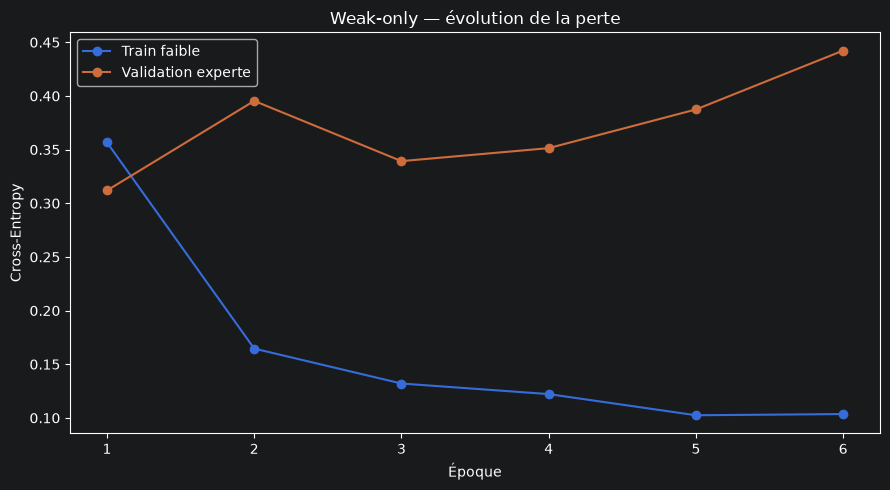

In [61]:
plt.figure(figsize=(9, 5))

plt.plot(
    historique_weak_only["epoque"],
    historique_weak_only["train_loss"],
    marker="o",
    label="Train faible",
)

plt.plot(
    historique_weak_only["epoque"],
    historique_weak_only[
        "validation_loss"
    ],
    marker="o",
    label="Validation experte",
)

plt.xlabel("Époque")
plt.ylabel("Cross-Entropy")
plt.title(
    "Weak-only — évolution de la perte"
)

plt.legend()
plt.tight_layout()
plt.show()

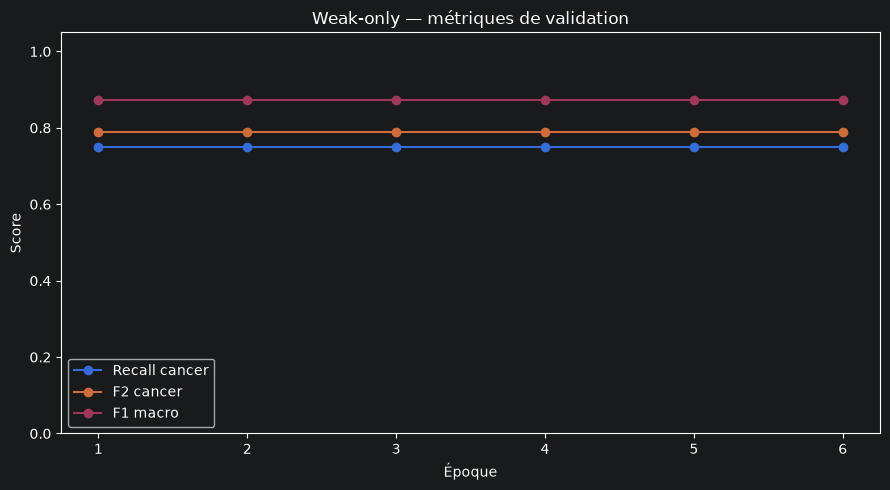

In [62]:
plt.figure(figsize=(9, 5))

plt.plot(
    historique_weak_only["epoque"],
    historique_weak_only[
        "validation_recall_cancer"
    ],
    marker="o",
    label="Recall cancer",
)

plt.plot(
    historique_weak_only["epoque"],
    historique_weak_only[
        "validation_f2_cancer"
    ],
    marker="o",
    label="F2 cancer",
)

plt.plot(
    historique_weak_only["epoque"],
    historique_weak_only[
        "validation_f1_macro"
    ],
    marker="o",
    label="F1 macro",
)

plt.xlabel("Époque")
plt.ylabel("Score")
plt.ylim(0.0, 1.05)

plt.title(
    "Weak-only — métriques de validation"
)

plt.legend()
plt.tight_layout()
plt.show()

In [63]:
criterion_validation = nn.CrossEntropyLoss(
    weight=poids_classes_weak.to(
        DEVICE
    ),
    reduction="none",
)

(
    metriques_weak_validation,
    details_weak_validation,
) = evaluer_modele(
    modele=modele_weak_only,
    data_loader=strong_validation_loader,
    criterion=criterion_validation,
    device=DEVICE,
)

display(
    pd.DataFrame(
        [
            metriques_weak_validation
        ],
        index=[
            "weak_only_validation"
        ],
    )
)

,accuracy,balanced_accuracy,precision_cancer,recall_cancer,f1_cancer,f2_cancer,f1_macro,roc_auc,average_precision,loss
weak_only_validation,0.875,0.875,1.0,0.75,0.857143,0.789474,0.873016,0.953125,0.965909,0.311928


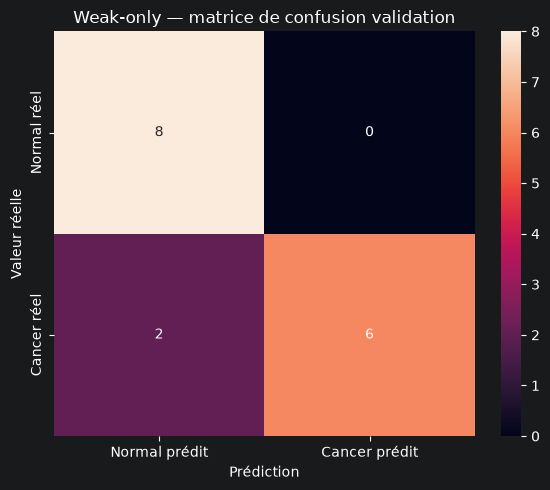

In [64]:
matrice_weak_validation = confusion_matrix(
    details_weak_validation[
        "y_true"
    ],
    details_weak_validation[
        "y_pred"
    ],
    labels=[0, 1],
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matrice_weak_validation,
    annot=True,
    fmt="d",
    xticklabels=[
        "Normal prédit",
        "Cancer prédit",
    ],
    yticklabels=[
        "Normal réel",
        "Cancer réel",
    ],
)

plt.title(
    "Weak-only — matrice de confusion validation"
)

plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

plt.tight_layout()
plt.show()

## 14. Interprétation de l'apprentissage faible

Le meilleur checkpoint `weak_only` est obtenu dès la première époque.

Sur les 16 images expertes de validation, il obtient :

- 8 vrais négatifs ;
- 0 faux positif ;
- 2 faux négatifs ;
- 6 vrais positifs.

Le rappel de la classe cancer atteint 0,75 : le modèle détecte six des
huit images cancéreuses, mais en classe encore deux comme normales.

La précision cancer est égale à 1, car aucune image normale n'est
prédite cancéreuse.

La diminution continue de la perte d'entraînement, accompagnée d'une
augmentation de la perte de validation, montre que le modèle commence à
surapprendre les labels faibles après la première époque.

Le checkpoint sélectionné par early stopping est donc conservé avant de
poursuivre l'entraînement sur les labels experts.

In [65]:
tn_weak, fp_weak, fn_weak, tp_weak = (
    matrice_weak_validation.ravel()
)

print(f"Vrais négatifs  — TN : {tn_weak}")
print(f"Faux positifs   — FP : {fp_weak}")
print(f"Faux négatifs   — FN : {fn_weak}")
print(f"Vrais positifs  — TP : {tp_weak}")

assert tn_weak == 8
assert fp_weak == 0
assert fn_weak == 2
assert tp_weak == 6

Vrais négatifs  — TN : 8
Faux positifs   — FP : 0
Faux négatifs   — FN : 2
Vrais positifs  — TP : 6


## 15. Fine-tuning avec les labels experts

Le modèle semi-supervisé reprend exactement les paramètres du meilleur
checkpoint `weak_only`.

Pour limiter le surapprentissage sur seulement 64 annotations expertes :

- les couches `conv1`, `layer1`, `layer2` et `layer3` restent gelées ;
- le dernier bloc convolutif `layer4` est dégelé ;
- le classifieur final `fc` reste entraînable ;
- un learning rate plus faible est utilisé.

La validation experte contrôle l'early stopping. Le test final reste
exclu.

In [66]:
def configurer_fine_tuning_layer4(
    modele: nn.Module,
) -> nn.Module:
    """
    Gèle l'ensemble du modèle puis dégèle layer4 et fc.
    """

    for parameter in modele.parameters():
        parameter.requires_grad = False

    for parameter in modele.layer4.parameters():
        parameter.requires_grad = True

    for parameter in modele.fc.parameters():
        parameter.requires_grad = True

    return modele

In [67]:
def charger_checkpoint_torch(
    checkpoint_path: Path,
) -> dict:
    """
    Charge un checkpoint PyTorch sur le CPU.

    Le bloc try/except assure une compatibilité avec plusieurs
    versions de PyTorch.
    """

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint introuvable : {checkpoint_path}"
        )

    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )

    except TypeError:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
        )

    return checkpoint

In [68]:
checkpoint_weak_only = (
    charger_checkpoint_torch(
        WEAK_ONLY_CHECKPOINT_PATH
    )
)

print(
    "Expérience chargée :",
    checkpoint_weak_only["experience"],
)

print(
    "Meilleure époque weak-only :",
    checkpoint_weak_only[
        "meilleure_epoque"
    ],
)

assert (
    checkpoint_weak_only["experience"]
    == "weak_only"
)

Expérience chargée : weak_only
Meilleure époque weak-only : 1


In [69]:
fixer_aleatoire(RANDOM_STATE)

modele_semi_supervised = (
    creer_resnet18_classification(
        nombre_classes=2
    )
)

modele_semi_supervised.load_state_dict(
    checkpoint_weak_only[
        "model_state_dict"
    ]
)

modele_semi_supervised = (
    configurer_fine_tuning_layer4(
        modele_semi_supervised
    )
)

In [70]:
nombre_parametres_total_semi = sum(
    parameter.numel()
    for parameter
    in modele_semi_supervised.parameters()
)

nombre_parametres_entrainables_semi = sum(
    parameter.numel()
    for parameter
    in modele_semi_supervised.parameters()
    if parameter.requires_grad
)

print(
    "Paramètres totaux :",
    f"{nombre_parametres_total_semi:,}",
)

print(
    "Paramètres entraînables :",
    f"{nombre_parametres_entrainables_semi:,}",
)

print(
    "Proportion entraînable :",
    (
        100
        * nombre_parametres_entrainables_semi
        / nombre_parametres_total_semi
    ),
)

Paramètres totaux : 11,177,538
Paramètres entraînables : 8,394,754
Proportion entraînable : 75.10378403544681


In [71]:
poids_classes_strong = (
    calculer_poids_classes(
        df_strong_train[
            "label_id"
        ].to_numpy(dtype=int)
    )
)

print(
    "Répartition strong train :"
)

display(
    df_strong_train[
        "label"
    ]
    .value_counts()
    .rename_axis("label")
    .reset_index(
        name="nombre_images"
    )
)

print(
    "Poids des classes expertes :",
    poids_classes_strong.tolist(),
)

Répartition strong train :


,label,nombre_images
0,cancer,32
1,normal,32


Poids des classes expertes : [1.0, 1.0]


In [72]:
SEMI_SUPERVISED_CHECKPOINT_PATH = (
    MODELS_DIR
    / "resnet18_semi_supervised.pt"
)

SEMI_SUPERVISED_HISTORY_PATH = (
    HISTORY_DIR
    / "semi_supervised_history.csv"
)

print(
    "Checkpoint semi-supervisé :",
    SEMI_SUPERVISED_CHECKPOINT_PATH,
)

print(
    "Historique semi-supervisé :",
    SEMI_SUPERVISED_HISTORY_PATH,
)

Checkpoint semi-supervisé : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/models/resnet18_semi_supervised.pt
Historique semi-supervisé : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/histories/semi_supervised_history.csv


In [73]:
MAX_EPOCHS_SEMI = 25
PATIENCE_SEMI = 7
LEARNING_RATE_SEMI = 1e-4

(
    modele_semi_supervised,
    historique_semi_supervised,
    resume_semi_supervised,
) = entrainer_modele(
    modele=modele_semi_supervised,
    train_loader=strong_train_loader,
    validation_loader=(
        strong_validation_loader
    ),
    poids_classes=poids_classes_strong,
    device=DEVICE,
    nombre_epoques=MAX_EPOCHS_SEMI,
    learning_rate=LEARNING_RATE_SEMI,
    patience=PATIENCE_SEMI,
    nom_experience="semi_supervised",
)

[semi_supervised] Époque 01/25 | train_loss=0.3131 | val_loss=0.2927 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[semi_supervised] Époque 02/25 | train_loss=0.1533 | val_loss=0.3636 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[semi_supervised] Époque 03/25 | train_loss=0.0390 | val_loss=0.3996 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[semi_supervised] Époque 04/25 | train_loss=0.0203 | val_loss=0.3135 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[semi_supervised] Époque 05/25 | train_loss=0.0458 | val_loss=0.3117 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[semi_supervised] Époque 06/25 | train_loss=0.0671 | val_loss=0.2677 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[semi_supervised] Époque 07/25 | train_loss=0.0076 | val_loss=0.2504 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[semi_supervised] Époque 08/25 | train_loss=0.0395 | val_loss=0.2575 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
Early stopping : aucune 

In [74]:
print(
    "Meilleure époque semi-supervisée :",
    resume_semi_supervised[
        "meilleure_epoque"
    ],
)

display(
    pd.DataFrame(
        [
            resume_semi_supervised[
                "metriques_validation"
            ]
        ]
    ).T.rename(
        columns={
            0: "semi_supervised_validation"
        }
    )
)

Meilleure époque semi-supervisée : 1


,semi_supervised_validation
accuracy,0.937500
balanced_accuracy,0.937500
precision_cancer,1.000000
recall_cancer,0.875000
f1_cancer,0.933333
f2_cancer,0.897436
f1_macro,0.937255
roc_auc,0.906250
average_precision,0.946429
loss,0.292732


In [75]:
torch.save(
    {
        "architecture": "resnet18",
        "experience": "semi_supervised",
        "nombre_classes": 2,
        "random_state": RANDOM_STATE,
        "initialisation": (
            "checkpoint_weak_only"
        ),
        "couches_degelees": [
            "layer4",
            "fc",
        ],
        "learning_rate": (
            LEARNING_RATE_SEMI
        ),
        "meilleure_epoque": (
            resume_semi_supervised[
                "meilleure_epoque"
            ]
        ),
        "metriques_validation": (
            resume_semi_supervised[
                "metriques_validation"
            ]
        ),
        "model_state_dict": (
            resume_semi_supervised[
                "state_dict"
            ]
        ),
    },
    SEMI_SUPERVISED_CHECKPOINT_PATH,
)

historique_semi_supervised.to_csv(
    SEMI_SUPERVISED_HISTORY_PATH,
    index=False,
)

print(
    "Checkpoint sauvegardé :",
    SEMI_SUPERVISED_CHECKPOINT_PATH,
)

print(
    "Historique sauvegardé :",
    SEMI_SUPERVISED_HISTORY_PATH,
)

Checkpoint sauvegardé : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/models/resnet18_semi_supervised.pt
Historique sauvegardé : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/histories/semi_supervised_history.csv


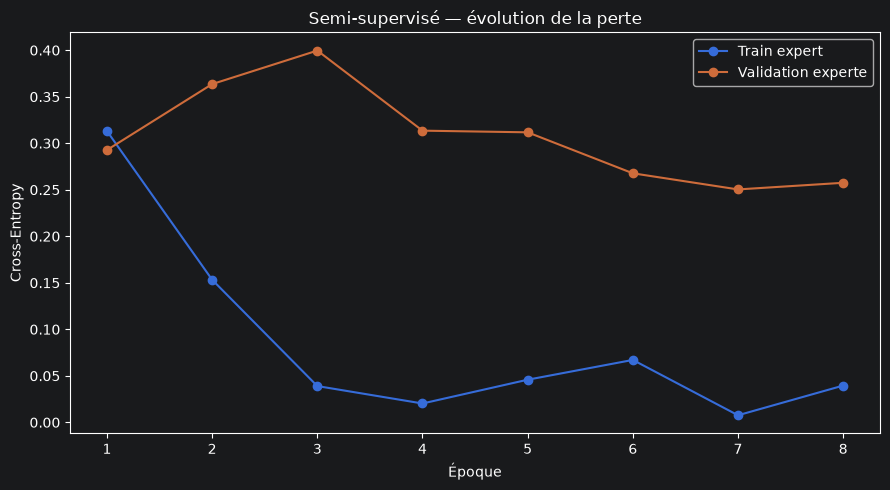

In [76]:
plt.figure(figsize=(9, 5))

plt.plot(
    historique_semi_supervised[
        "epoque"
    ],
    historique_semi_supervised[
        "train_loss"
    ],
    marker="o",
    label="Train expert",
)

plt.plot(
    historique_semi_supervised[
        "epoque"
    ],
    historique_semi_supervised[
        "validation_loss"
    ],
    marker="o",
    label="Validation experte",
)

plt.xlabel("Époque")
plt.ylabel("Cross-Entropy")

plt.title(
    "Semi-supervisé — évolution de la perte"
)

plt.legend()
plt.tight_layout()
plt.show()

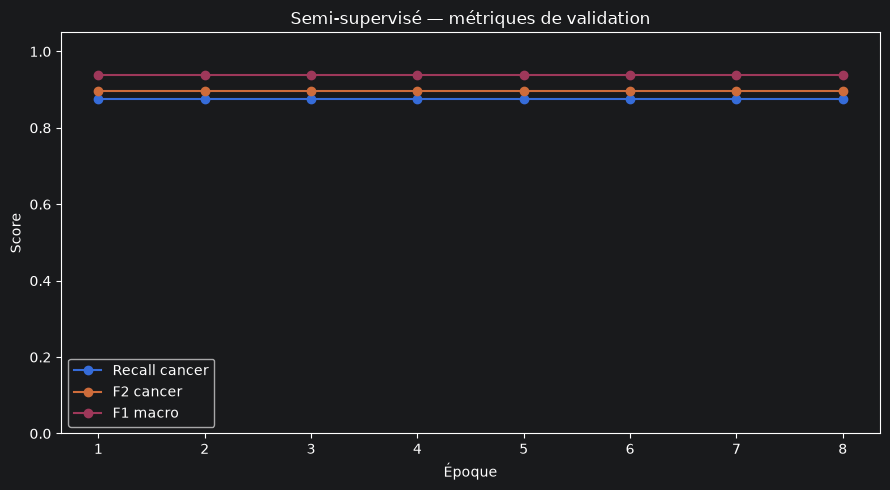

In [77]:
plt.figure(figsize=(9, 5))

plt.plot(
    historique_semi_supervised[
        "epoque"
    ],
    historique_semi_supervised[
        "validation_recall_cancer"
    ],
    marker="o",
    label="Recall cancer",
)

plt.plot(
    historique_semi_supervised[
        "epoque"
    ],
    historique_semi_supervised[
        "validation_f2_cancer"
    ],
    marker="o",
    label="F2 cancer",
)

plt.plot(
    historique_semi_supervised[
        "epoque"
    ],
    historique_semi_supervised[
        "validation_f1_macro"
    ],
    marker="o",
    label="F1 macro",
)

plt.xlabel("Époque")
plt.ylabel("Score")
plt.ylim(0.0, 1.05)

plt.title(
    "Semi-supervisé — métriques de validation"
)

plt.legend()
plt.tight_layout()
plt.show()

In [78]:
criterion_strong_validation = (
    nn.CrossEntropyLoss(
        weight=poids_classes_strong.to(
            DEVICE
        ),
        reduction="none",
    )
)

(
    metriques_semi_validation,
    details_semi_validation,
) = evaluer_modele(
    modele=modele_semi_supervised,
    data_loader=strong_validation_loader,
    criterion=criterion_strong_validation,
    device=DEVICE,
)

display(
    pd.DataFrame(
        [
            metriques_semi_validation
        ],
        index=[
            "semi_supervised_validation"
        ],
    )
)

,accuracy,balanced_accuracy,precision_cancer,recall_cancer,f1_cancer,f2_cancer,f1_macro,roc_auc,average_precision,loss
semi_supervised_validation,0.9375,0.9375,1.0,0.875,0.933333,0.897436,0.937255,0.90625,0.946429,0.292732


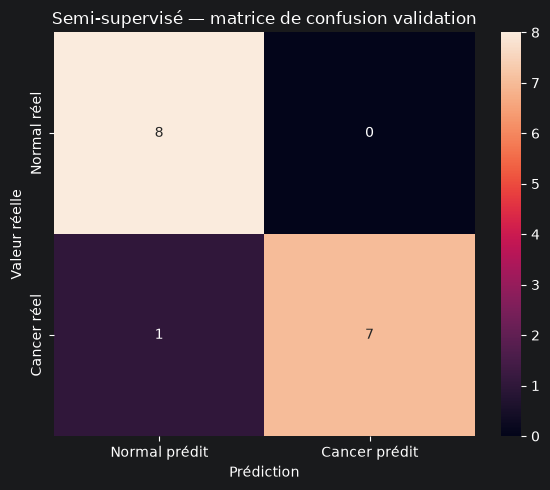

In [79]:
matrice_semi_validation = (
    confusion_matrix(
        details_semi_validation[
            "y_true"
        ],
        details_semi_validation[
            "y_pred"
        ],
        labels=[0, 1],
    )
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matrice_semi_validation,
    annot=True,
    fmt="d",
    xticklabels=[
        "Normal prédit",
        "Cancer prédit",
    ],
    yticklabels=[
        "Normal réel",
        "Cancer réel",
    ],
)

plt.title(
    "Semi-supervisé — matrice de confusion validation"
)

plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

plt.tight_layout()
plt.show()

In [80]:
comparaison_validation_intermediaire = (
    pd.DataFrame(
        [
            {
                "modele": "weak_only",
                **metriques_weak_validation,
            },
            {
                "modele": "semi_supervised",
                **metriques_semi_validation,
            },
        ]
    )
    .set_index("modele")
)

display(
    comparaison_validation_intermediaire
)

,accuracy,balanced_accuracy,precision_cancer,recall_cancer,f1_cancer,f2_cancer,f1_macro,roc_auc,average_precision,loss
modele,,,,,,,,,,
weak_only,0.8750,0.8750,1.0,0.750,0.857143,0.789474,0.873016,0.953125,0.965909,0.311928
semi_supervised,0.9375,0.9375,1.0,0.875,0.933333,0.897436,0.937255,0.906250,0.946429,0.292732


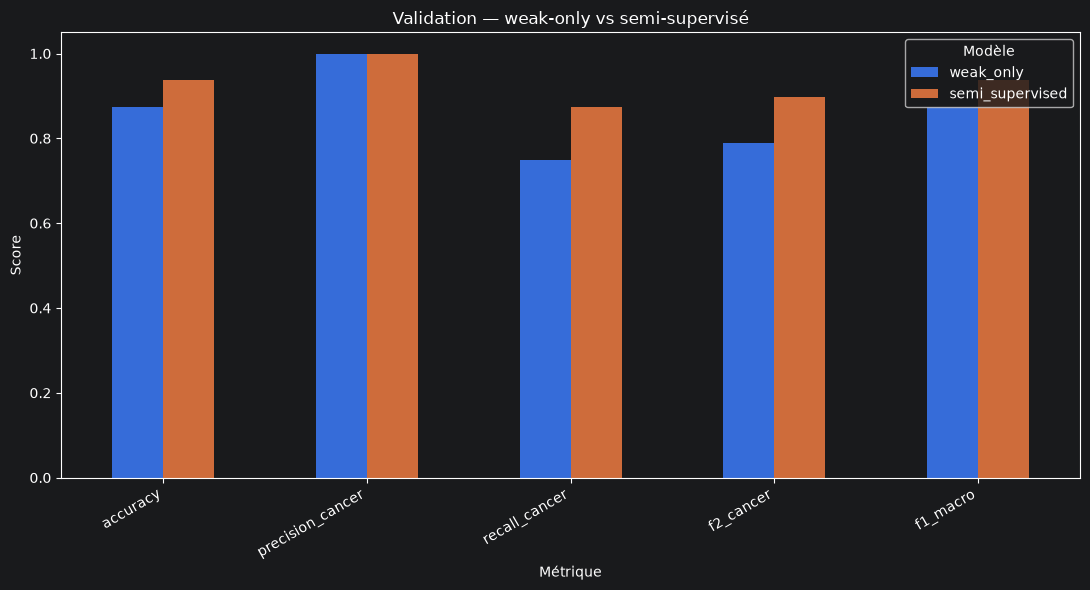

In [81]:
metriques_comparaison = [
    "accuracy",
    "precision_cancer",
    "recall_cancer",
    "f2_cancer",
    "f1_macro",
]

comparaison_validation_intermediaire[
    metriques_comparaison
].T.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.title(
    "Validation — weak-only vs semi-supervisé"
)

plt.xlabel("Métrique")
plt.ylabel("Score")
plt.ylim(0.0, 1.05)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.legend(
    title="Modèle"
)

plt.tight_layout()
plt.show()

## 16. Modèle supervisé de référence

Le modèle supervisé constitue le point de comparaison principal du modèle
semi-supervisé.

Il est initialisé avec les poids ImageNet et entraîné uniquement sur les
64 images disposant d'un label expert.

Afin de rendre la comparaison équitable :

- l'architecture reste ResNet-18 ;
- les couches `layer4` et `fc` sont entraînables ;
- le même jeu expert d'entraînement est utilisé ;
- le même jeu expert de validation est utilisé ;
- les mêmes hyperparamètres sont appliqués ;
- le meilleur checkpoint est choisi selon le F2-score cancer.

Contrairement au modèle semi-supervisé, ce modèle ne voit jamais les
1 406 images faiblement labellisées.

In [82]:
def creer_strong_train_loader(
    seed: int,
) -> DataLoader:
    """
    Crée un DataLoader reproductible pour le train expert.
    """

    generateur = torch.Generator()
    generateur.manual_seed(seed)

    return DataLoader(
        strong_train_dataset,
        batch_size=BATCH_SIZE_STRONG,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        drop_last=False,
        generator=generateur,
    )


strong_train_loader_supervised = (
    creer_strong_train_loader(
        seed=RANDOM_STATE,
    )
)

print(
    "Nombre de batchs supervisés :",
    len(strong_train_loader_supervised),
)

Nombre de batchs supervisés : 8


In [83]:
fixer_aleatoire(RANDOM_STATE)

modele_supervised = (
    creer_resnet18_classification(
        nombre_classes=2
    )
)

modele_supervised.load_state_dict(
    etat_initial_resnet18
)

modele_supervised = (
    configurer_fine_tuning_layer4(
        modele_supervised
    )
)

In [84]:
nombre_parametres_total_supervised = sum(
    parameter.numel()
    for parameter
    in modele_supervised.parameters()
)

nombre_parametres_entrainables_supervised = sum(
    parameter.numel()
    for parameter
    in modele_supervised.parameters()
    if parameter.requires_grad
)

print(
    "Paramètres totaux :",
    f"{nombre_parametres_total_supervised:,}",
)

print(
    "Paramètres entraînables :",
    f"{nombre_parametres_entrainables_supervised:,}",
)

print(
    "Proportion entraînable :",
    (
        100
        * nombre_parametres_entrainables_supervised
        / nombre_parametres_total_supervised
    ),
)

Paramètres totaux : 11,177,538
Paramètres entraînables : 8,394,754
Proportion entraînable : 75.10378403544681


In [85]:
assert (
    nombre_parametres_entrainables_supervised
    == nombre_parametres_entrainables_semi
)

print(
    "Validation réussie : les modèles supervisé et "
    "semi-supervisé ont la même architecture entraînable."
)

Validation réussie : les modèles supervisé et semi-supervisé ont la même architecture entraînable.


In [86]:
SUPERVISED_CHECKPOINT_PATH = (
    MODELS_DIR
    / "resnet18_supervised.pt"
)

SUPERVISED_HISTORY_PATH = (
    HISTORY_DIR
    / "supervised_history.csv"
)

print(
    "Checkpoint supervisé :",
    SUPERVISED_CHECKPOINT_PATH,
)

print(
    "Historique supervisé :",
    SUPERVISED_HISTORY_PATH,
)

Checkpoint supervisé : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/models/resnet18_supervised.pt
Historique supervisé : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/histories/supervised_history.csv


In [87]:
MAX_EPOCHS_SUPERVISED = MAX_EPOCHS_SEMI
PATIENCE_SUPERVISED = PATIENCE_SEMI
LEARNING_RATE_SUPERVISED = LEARNING_RATE_SEMI

print(
    "Nombre maximal d'époques :",
    MAX_EPOCHS_SUPERVISED,
)

print(
    "Patience :",
    PATIENCE_SUPERVISED,
)

print(
    "Learning rate :",
    LEARNING_RATE_SUPERVISED,
)

Nombre maximal d'époques : 25
Patience : 7
Learning rate : 0.0001


In [88]:
(
    modele_supervised,
    historique_supervised,
    resume_supervised,
) = entrainer_modele(
    modele=modele_supervised,
    train_loader=(
        strong_train_loader_supervised
    ),
    validation_loader=(
        strong_validation_loader
    ),
    poids_classes=poids_classes_strong,
    device=DEVICE,
    nombre_epoques=(
        MAX_EPOCHS_SUPERVISED
    ),
    learning_rate=(
        LEARNING_RATE_SUPERVISED
    ),
    patience=PATIENCE_SUPERVISED,
    nom_experience="supervised",
)

[supervised] Époque 01/25 | train_loss=0.4003 | val_loss=0.2623 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[supervised] Époque 02/25 | train_loss=0.1727 | val_loss=0.1986 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[supervised] Époque 03/25 | train_loss=0.1503 | val_loss=0.2302 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[supervised] Époque 04/25 | train_loss=0.0846 | val_loss=0.2511 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[supervised] Époque 05/25 | train_loss=0.0201 | val_loss=0.2370 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[supervised] Époque 06/25 | train_loss=0.0661 | val_loss=0.2227 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[supervised] Époque 07/25 | train_loss=0.0092 | val_loss=0.2159 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
[supervised] Époque 08/25 | train_loss=0.0561 | val_loss=0.1942 | recall_cancer=0.8750 | F2=0.8974 | F1_macro=0.9373
Early stopping : aucune amélioration du F2 pendant 7 époques.


In [89]:
print(
    "Meilleure époque supervisée :",
    resume_supervised[
        "meilleure_epoque"
    ],
)

display(
    pd.DataFrame(
        [
            resume_supervised[
                "metriques_validation"
            ]
        ]
    ).T.rename(
        columns={
            0: "supervised_validation"
        }
    )
)

Meilleure époque supervisée : 1


,supervised_validation
accuracy,0.937500
balanced_accuracy,0.937500
precision_cancer,1.000000
recall_cancer,0.875000
f1_cancer,0.933333
f2_cancer,0.897436
f1_macro,0.937255
roc_auc,0.953125
average_precision,0.965909
loss,0.262270


In [90]:
torch.save(
    {
        "architecture": "resnet18",
        "experience": "supervised",
        "nombre_classes": 2,
        "random_state": RANDOM_STATE,
        "initialisation": "imagenet",
        "donnees_entrainement": (
            "strong_train_only"
        ),
        "nombre_images_train": int(
            len(df_strong_train)
        ),
        "couches_degelees": [
            "layer4",
            "fc",
        ],
        "learning_rate": (
            LEARNING_RATE_SUPERVISED
        ),
        "meilleure_epoque": (
            resume_supervised[
                "meilleure_epoque"
            ]
        ),
        "metriques_validation": (
            resume_supervised[
                "metriques_validation"
            ]
        ),
        "model_state_dict": (
            resume_supervised[
                "state_dict"
            ]
        ),
    },
    SUPERVISED_CHECKPOINT_PATH,
)

historique_supervised.to_csv(
    SUPERVISED_HISTORY_PATH,
    index=False,
)

print(
    "Checkpoint sauvegardé :",
    SUPERVISED_CHECKPOINT_PATH,
)

print(
    "Historique sauvegardé :",
    SUPERVISED_HISTORY_PATH,
)

Checkpoint sauvegardé : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/models/resnet18_supervised.pt
Historique sauvegardé : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/histories/supervised_history.csv


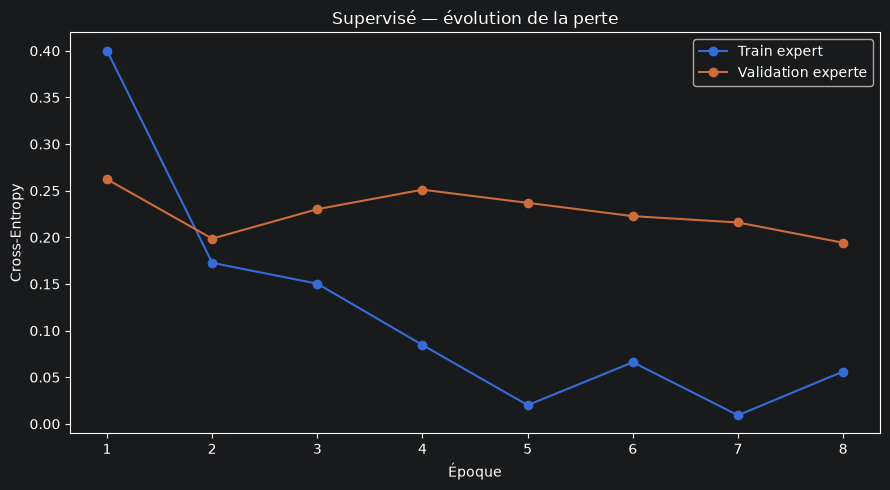

In [91]:
plt.figure(figsize=(9, 5))

plt.plot(
    historique_supervised[
        "epoque"
    ],
    historique_supervised[
        "train_loss"
    ],
    marker="o",
    label="Train expert",
)

plt.plot(
    historique_supervised[
        "epoque"
    ],
    historique_supervised[
        "validation_loss"
    ],
    marker="o",
    label="Validation experte",
)

plt.xlabel("Époque")
plt.ylabel("Cross-Entropy")

plt.title(
    "Supervisé — évolution de la perte"
)

plt.legend()
plt.tight_layout()
plt.show()

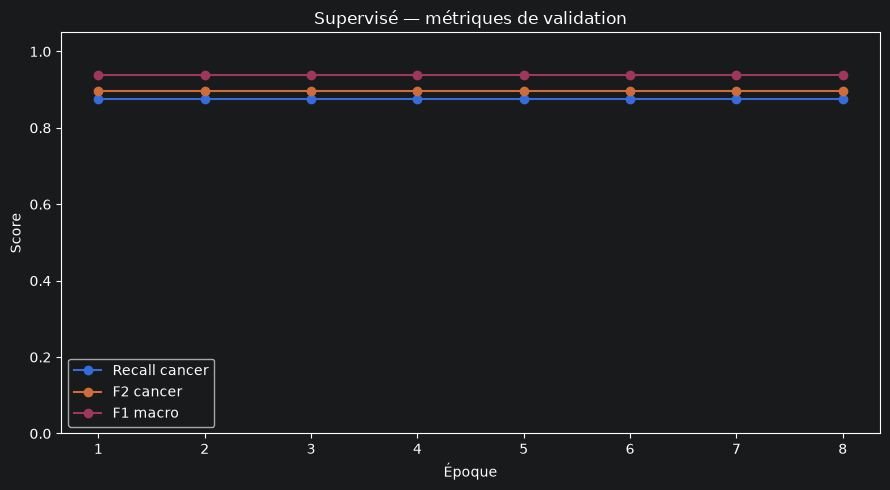

In [92]:
plt.figure(figsize=(9, 5))

plt.plot(
    historique_supervised[
        "epoque"
    ],
    historique_supervised[
        "validation_recall_cancer"
    ],
    marker="o",
    label="Recall cancer",
)

plt.plot(
    historique_supervised[
        "epoque"
    ],
    historique_supervised[
        "validation_f2_cancer"
    ],
    marker="o",
    label="F2 cancer",
)

plt.plot(
    historique_supervised[
        "epoque"
    ],
    historique_supervised[
        "validation_f1_macro"
    ],
    marker="o",
    label="F1 macro",
)

plt.xlabel("Époque")
plt.ylabel("Score")
plt.ylim(0.0, 1.05)

plt.title(
    "Supervisé — métriques de validation"
)

plt.legend()
plt.tight_layout()
plt.show()

In [93]:
(
    metriques_supervised_validation,
    details_supervised_validation,
) = evaluer_modele(
    modele=modele_supervised,
    data_loader=strong_validation_loader,
    criterion=criterion_strong_validation,
    device=DEVICE,
)

display(
    pd.DataFrame(
        [
            metriques_supervised_validation
        ],
        index=[
            "supervised_validation"
        ],
    )
)

,accuracy,balanced_accuracy,precision_cancer,recall_cancer,f1_cancer,f2_cancer,f1_macro,roc_auc,average_precision,loss
supervised_validation,0.9375,0.9375,1.0,0.875,0.933333,0.897436,0.937255,0.953125,0.965909,0.26227


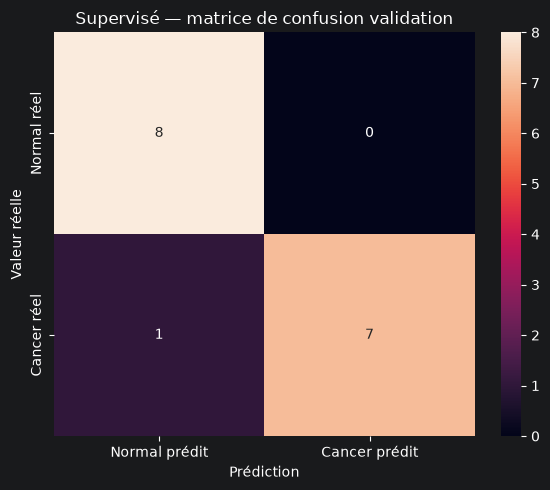

In [94]:
matrice_supervised_validation = (
    confusion_matrix(
        details_supervised_validation[
            "y_true"
        ],
        details_supervised_validation[
            "y_pred"
        ],
        labels=[0, 1],
    )
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matrice_supervised_validation,
    annot=True,
    fmt="d",
    xticklabels=[
        "Normal prédit",
        "Cancer prédit",
    ],
    yticklabels=[
        "Normal réel",
        "Cancer réel",
    ],
)

plt.title(
    "Supervisé — matrice de confusion validation"
)

plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

plt.tight_layout()
plt.show()

In [95]:
(
    tn_supervised,
    fp_supervised,
    fn_supervised,
    tp_supervised,
) = matrice_supervised_validation.ravel()

print(
    f"Vrais négatifs — TN : "
    f"{tn_supervised}"
)

print(
    f"Faux positifs — FP : "
    f"{fp_supervised}"
)

print(
    f"Faux négatifs — FN : "
    f"{fn_supervised}"
)

print(
    f"Vrais positifs — TP : "
    f"{tp_supervised}"
)

Vrais négatifs — TN : 8
Faux positifs — FP : 0
Faux négatifs — FN : 1
Vrais positifs — TP : 7


In [96]:
(
    metriques_weak_validation_harmonisees,
    details_weak_validation_harmonises,
) = evaluer_modele(
    modele=modele_weak_only,
    data_loader=strong_validation_loader,
    criterion=criterion_strong_validation,
    device=DEVICE,
)

(
    metriques_semi_validation_harmonisees,
    details_semi_validation_harmonises,
) = evaluer_modele(
    modele=modele_semi_supervised,
    data_loader=strong_validation_loader,
    criterion=criterion_strong_validation,
    device=DEVICE,
)

(
    metriques_supervised_validation_harmonisees,
    details_supervised_validation_harmonises,
) = evaluer_modele(
    modele=modele_supervised,
    data_loader=strong_validation_loader,
    criterion=criterion_strong_validation,
    device=DEVICE,
)

print(
    "Les trois modèles ont été réévalués avec "
    "le même protocole de validation."
)

Les trois modèles ont été réévalués avec le même protocole de validation.


In [97]:
comparaison_validation_complete = (
    pd.DataFrame(
        [
            {
                "modele": "weak_only",
                **(
                    metriques_weak_validation_harmonisees
                ),
            },
            {
                "modele": "semi_supervised",
                **(
                    metriques_semi_validation_harmonisees
                ),
            },
            {
                "modele": "supervised",
                **(
                    metriques_supervised_validation_harmonisees
                ),
            },
        ]
    )
    .set_index("modele")
)

display(
    comparaison_validation_complete
)

,accuracy,balanced_accuracy,precision_cancer,recall_cancer,f1_cancer,f2_cancer,f1_macro,roc_auc,average_precision,loss
modele,,,,,,,,,,
weak_only,0.8750,0.8750,1.0,0.750,0.857143,0.789474,0.873016,0.953125,0.965909,0.323597
semi_supervised,0.9375,0.9375,1.0,0.875,0.933333,0.897436,0.937255,0.906250,0.946429,0.292732
supervised,0.9375,0.9375,1.0,0.875,0.933333,0.897436,0.937255,0.953125,0.965909,0.262270


semi-supervisé contre supervisé

In [98]:
metriques_principales = [
    "accuracy",
    "balanced_accuracy",
    "precision_cancer",
    "recall_cancer",
    "f1_cancer",
    "f2_cancer",
    "f1_macro",
    "roc_auc",
    "average_precision",
]

gains_semi_vs_supervised_validation = (
    comparaison_validation_complete
    .loc[
        "semi_supervised",
        metriques_principales,
    ]
    - comparaison_validation_complete
    .loc[
        "supervised",
        metriques_principales,
    ]
)

df_gains_validation = (
    gains_semi_vs_supervised_validation
    .rename(
        "gain_semi_vs_supervised"
    )
    .to_frame()
)

display(
    df_gains_validation
)

,gain_semi_vs_supervised
accuracy,0.000000
balanced_accuracy,0.000000
precision_cancer,0.000000
recall_cancer,0.000000
f1_cancer,0.000000
f2_cancer,0.000000
f1_macro,0.000000
roc_auc,-0.046875
average_precision,-0.019481


### Lecture du tableau des gains

- valeur positive : avantage au modèle semi-supervisé ;
- valeur nulle : performances identiques ;
- valeur négative : avantage au modèle supervisé.

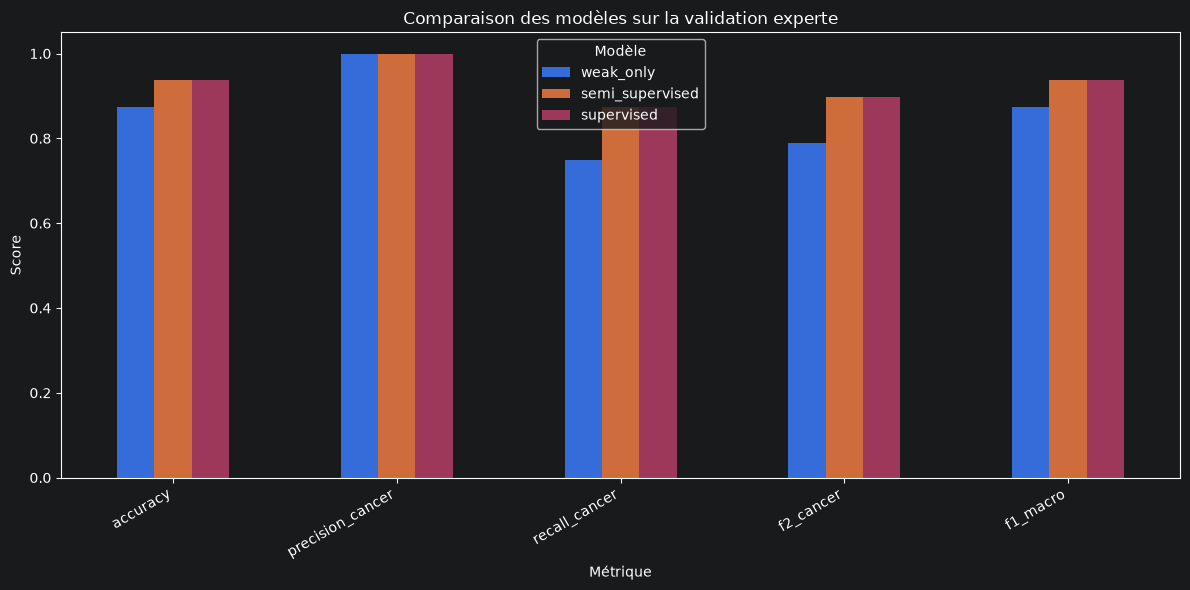

In [99]:
metriques_graphique = [
    "accuracy",
    "precision_cancer",
    "recall_cancer",
    "f2_cancer",
    "f1_macro",
]

comparaison_validation_complete[
    metriques_graphique
].T.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.title(
    "Comparaison des modèles sur la validation experte"
)

plt.xlabel("Métrique")
plt.ylabel("Score")
plt.ylim(0.0, 1.05)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.legend(
    title="Modèle"
)

plt.tight_layout()
plt.show()

In [100]:
matrices_validation = {
    "Weak-only": confusion_matrix(
        details_weak_validation_harmonises[
            "y_true"
        ],
        details_weak_validation_harmonises[
            "y_pred"
        ],
        labels=[0, 1],
    ),
    "Semi-supervisé": confusion_matrix(
        details_semi_validation_harmonises[
            "y_true"
        ],
        details_semi_validation_harmonises[
            "y_pred"
        ],
        labels=[0, 1],
    ),
    "Supervisé": confusion_matrix(
        details_supervised_validation_harmonises[
            "y_true"
        ],
        details_supervised_validation_harmonises[
            "y_pred"
        ],
        labels=[0, 1],
    ),
}

for nom_modele, matrice in (
    matrices_validation.items()
):
    tn, fp, fn, tp = matrice.ravel()

    print(nom_modele)
    print(
        f"TN={tn} | FP={fp} | "
        f"FN={fn} | TP={tp}"
    )
    print()

Weak-only
TN=8 | FP=0 | FN=2 | TP=6

Semi-supervisé
TN=8 | FP=0 | FN=1 | TP=7

Supervisé
TN=8 | FP=0 | FN=1 | TP=7



In [101]:
VALIDATION_COMPARISON_PATH = (
    SEMI_SUPERVISED_DIR
    / "validation_model_comparison.csv"
)

VALIDATION_GAINS_PATH = (
    SEMI_SUPERVISED_DIR
    / "validation_semi_vs_supervised_gains.csv"
)

comparaison_validation_complete.to_csv(
    VALIDATION_COMPARISON_PATH
)

df_gains_validation.to_csv(
    VALIDATION_GAINS_PATH
)

print(
    "Comparaison sauvegardée :",
    VALIDATION_COMPARISON_PATH,
)

print(
    "Gains sauvegardés :",
    VALIDATION_GAINS_PATH,
)

Comparaison sauvegardée : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/validation_model_comparison.csv
Gains sauvegardés : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/validation_semi_vs_supervised_gains.csv


## 17. Sélection des modèles avant le test final

Trois modèles ont été entraînés :

1. `weak_only` : entraînement sur les 1 406 labels faibles ;
2. `semi_supervised` : poursuite du modèle `weak_only` sur les
   64 labels experts ;
3. `supervised` : entraînement uniquement sur les 64 labels experts.

Les meilleurs checkpoints ont été sélectionnés uniquement à partir des
16 images expertes de validation.

Le jeu de test final contient 20 images équilibrées :

- 10 images normales ;
- 10 images cancéreuses.

Aucune de ces images n'a été utilisée pour :

- entraîner les CNN ;
- créer les labels faibles ;
- déterminer le mapping entre clusters et classes ;
- choisir une époque ;
- régler le learning rate ;
- effectuer l'early stopping.

Le test final sera utilisé une seule fois pour comparer les modèles
sélectionnés.

## 18. Évaluation finale sur le jeu de test

Les trois modèles ont été entièrement entraînés et sélectionnés avant
l'ouverture du jeu de test :

1. `weak_only` : entraîné uniquement sur les 1 406 labels faibles ;
2. `semi_supervised` : modèle `weak_only` poursuivi sur les 64 labels
   experts ;
3. `supervised` : modèle initialisé avec les poids ImageNet et entraîné
   uniquement sur les 64 labels experts.

Le jeu de test contient 20 images expertes équilibrées :

- 10 images normales ;
- 10 images cancéreuses.

Le seuil de décision reste fixé à 0,5. Il n'est pas ajusté sur le test.

Les résultats obtenus constituent l'estimation finale de cette
expérience. Aucun réentraînement ou réglage d'hyperparamètre ne sera
effectué à partir des performances du test.

94. Vérifier les éléments nécessaires

In [102]:
elements_requis = [
    "strong_test_loader",
    "poids_classes_strong",
    "evaluer_modele",
    "creer_resnet18_classification",
    "charger_checkpoint_torch",
    "MODELS_DIR",
    "DEVICE",
]

elements_manquants = [
    nom
    for nom in elements_requis
    if nom not in globals()
]

if elements_manquants:
    raise NameError(
        "Éléments absents du kernel : "
        + ", ".join(elements_manquants)
        + ". Relance les cellules précédentes."
    )

print(
    "Tous les éléments nécessaires à "
    "l'évaluation finale sont disponibles."
)

Tous les éléments nécessaires à l'évaluation finale sont disponibles.


In [103]:
WEAK_ONLY_CHECKPOINT_PATH = (
    MODELS_DIR
    / "resnet18_weak_only.pt"
)

SEMI_SUPERVISED_CHECKPOINT_PATH = (
    MODELS_DIR
    / "resnet18_semi_supervised.pt"
)

SUPERVISED_CHECKPOINT_PATH = (
    MODELS_DIR
    / "resnet18_supervised.pt"
)

checkpoint_paths = {
    "weak_only": (
        WEAK_ONLY_CHECKPOINT_PATH
    ),
    "semi_supervised": (
        SEMI_SUPERVISED_CHECKPOINT_PATH
    ),
    "supervised": (
        SUPERVISED_CHECKPOINT_PATH
    ),
}

for nom_modele, chemin in checkpoint_paths.items():
    print(
        f"{nom_modele} : "
        f"{chemin.exists()} — {chemin}"
    )

    assert chemin.exists(), (
        f"Checkpoint introuvable : {chemin}"
    )

weak_only : True — /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/models/resnet18_weak_only.pt
semi_supervised : True — /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/models/resnet18_semi_supervised.pt
supervised : True — /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/models/resnet18_supervised.pt


96. Recharger exactement les checkpoints sélectionnés

Nous ne réutilisons pas directement les objets présents en mémoire. Nous rechargeons les fichiers sauvegardés afin d’être certains d’évaluer les meilleurs checkpoints retenus par l’early stopping.

In [104]:
def reconstruire_modele_depuis_checkpoint(
    checkpoint_path: Path,
    device: torch.device,
) -> tuple[nn.Module, dict]:
    """
    Reconstruit un ResNet-18 et charge le checkpoint demandé.
    """

    checkpoint = charger_checkpoint_torch(
        checkpoint_path
    )

    modele = creer_resnet18_classification(
        nombre_classes=2
    )

    modele.load_state_dict(
        checkpoint["model_state_dict"]
    )

    modele = modele.to(device)
    modele.eval()

    return modele, checkpoint

In [105]:
(
    modele_weak_test,
    checkpoint_weak_test,
) = reconstruire_modele_depuis_checkpoint(
    WEAK_ONLY_CHECKPOINT_PATH,
    DEVICE,
)

(
    modele_semi_test,
    checkpoint_semi_test,
) = reconstruire_modele_depuis_checkpoint(
    SEMI_SUPERVISED_CHECKPOINT_PATH,
    DEVICE,
)

(
    modele_supervised_test,
    checkpoint_supervised_test,
) = reconstruire_modele_depuis_checkpoint(
    SUPERVISED_CHECKPOINT_PATH,
    DEVICE,
)

print(
    "Checkpoint weak-only :",
    checkpoint_weak_test["experience"],
)

print(
    "Checkpoint semi-supervisé :",
    checkpoint_semi_test["experience"],
)

print(
    "Checkpoint supervisé :",
    checkpoint_supervised_test["experience"],
)

Checkpoint weak-only : weak_only
Checkpoint semi-supervisé : semi_supervised
Checkpoint supervisé : supervised


In [106]:
criterion_test = nn.CrossEntropyLoss(
    weight=poids_classes_strong.to(
        DEVICE
    ),
    reduction="none",
)

print(
    "Poids de classes utilisés pour le test :",
    poids_classes_strong.tolist(),
)

Poids de classes utilisés pour le test : [1.0, 1.0]


### Ouverture du test final

À partir de cette cellule, le jeu de test est ouvert.

Les résultats ne doivent plus être utilisés pour choisir une époque,
modifier un learning rate, changer une augmentation ou réentraîner un
modèle.

In [107]:
(
    metriques_weak_test,
    details_weak_test,
) = evaluer_modele(
    modele=modele_weak_test,
    data_loader=strong_test_loader,
    criterion=criterion_test,
    device=DEVICE,
)

(
    metriques_semi_test,
    details_semi_test,
) = evaluer_modele(
    modele=modele_semi_test,
    data_loader=strong_test_loader,
    criterion=criterion_test,
    device=DEVICE,
)

(
    metriques_supervised_test,
    details_supervised_test,
) = evaluer_modele(
    modele=modele_supervised_test,
    data_loader=strong_test_loader,
    criterion=criterion_test,
    device=DEVICE,
)

print(
    "Évaluation finale terminée pour "
    "les trois modèles."
)

Évaluation finale terminée pour les trois modèles.


In [108]:
assert (
    details_weak_test["paths"]
    == details_semi_test["paths"]
    == details_supervised_test["paths"]
)

assert np.array_equal(
    details_weak_test["y_true"],
    details_semi_test["y_true"],
)

assert np.array_equal(
    details_weak_test["y_true"],
    details_supervised_test["y_true"],
)

assert len(
    details_weak_test["y_true"]
) == 20

assert (
    np.bincount(
        details_weak_test["y_true"],
        minlength=2,
    ).tolist()
    == [10, 10]
)

print(
    "Validation réussie : les trois modèles ont été "
    "évalués sur les mêmes 20 images équilibrées."
)

Validation réussie : les trois modèles ont été évalués sur les mêmes 20 images équilibrées.


In [109]:
comparaison_test_final = (
    pd.DataFrame(
        [
            {
                "modele": "weak_only",
                **metriques_weak_test,
            },
            {
                "modele": "semi_supervised",
                **metriques_semi_test,
            },
            {
                "modele": "supervised",
                **metriques_supervised_test,
            },
        ]
    )
    .set_index("modele")
)

display(
    comparaison_test_final
)

,accuracy,balanced_accuracy,precision_cancer,recall_cancer,f1_cancer,f2_cancer,f1_macro,roc_auc,average_precision,loss
modele,,,,,,,,,,
weak_only,0.90,0.90,1.000000,0.8,0.888889,0.833333,0.898990,0.87,0.919841,0.370678
semi_supervised,0.95,0.95,1.000000,0.9,0.947368,0.918367,0.949875,0.99,0.990909,0.193850
supervised,0.95,0.95,0.909091,1.0,0.952381,0.980392,0.949875,1.00,1.000000,0.193567


In [110]:
details_test_par_modele = {
    "weak_only": details_weak_test,
    "semi_supervised": details_semi_test,
    "supervised": details_supervised_test,
}

lignes_confusion_test = []

for nom_modele, details in (
    details_test_par_modele.items()
):
    matrice = confusion_matrix(
        details["y_true"],
        details["y_pred"],
        labels=[0, 1],
    )

    tn, fp, fn, tp = matrice.ravel()

    lignes_confusion_test.append(
        {
            "modele": nom_modele,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp),
            "specificite_normal": float(
                tn / max(tn + fp, 1)
            ),
        }
    )

df_confusions_test = (
    pd.DataFrame(
        lignes_confusion_test
    )
    .set_index("modele")
)

comparaison_test_final = (
    comparaison_test_final.join(
        df_confusions_test
    )
)

display(
    comparaison_test_final
)

,accuracy,balanced_accuracy,precision_cancer,recall_cancer,f1_cancer,f2_cancer,f1_macro,roc_auc,average_precision,loss,TN,FP,FN,TP,specificite_normal
modele,,,,,,,,,,,,,,,
weak_only,0.90,0.90,1.000000,0.8,0.888889,0.833333,0.898990,0.87,0.919841,0.370678,10,0,2,8,1.0
semi_supervised,0.95,0.95,1.000000,0.9,0.947368,0.918367,0.949875,0.99,0.990909,0.193850,10,0,1,9,1.0
supervised,0.95,0.95,0.909091,1.0,0.952381,0.980392,0.949875,1.00,1.000000,0.193567,9,1,0,10,0.9


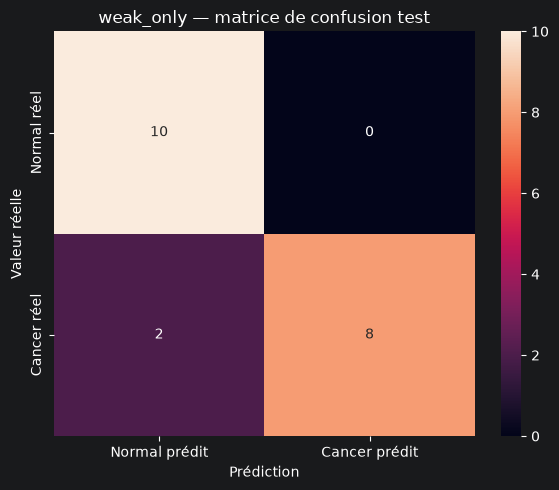

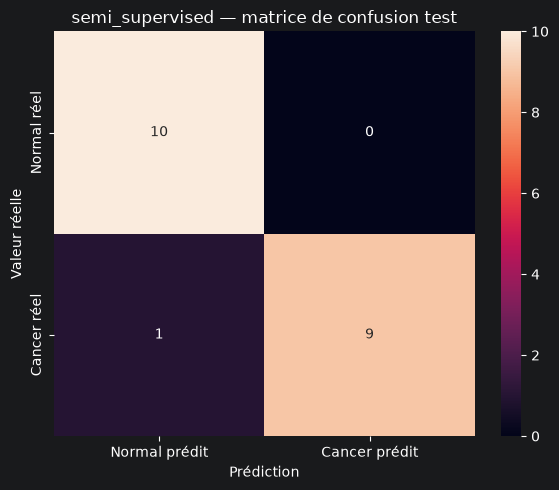

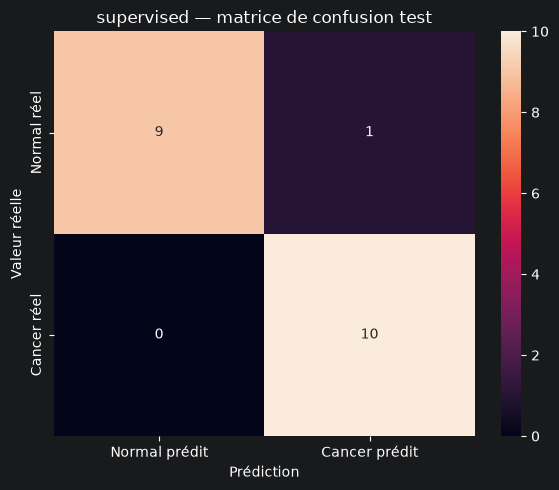

In [111]:
for nom_modele, details in (
    details_test_par_modele.items()
):
    matrice = confusion_matrix(
        details["y_true"],
        details["y_pred"],
        labels=[0, 1],
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        matrice,
        annot=True,
        fmt="d",
        xticklabels=[
            "Normal prédit",
            "Cancer prédit",
        ],
        yticklabels=[
            "Normal réel",
            "Cancer réel",
        ],
    )

    plt.title(
        f"{nom_modele} — matrice de confusion test"
    )

    plt.xlabel("Prédiction")
    plt.ylabel("Valeur réelle")

    plt.tight_layout()
    plt.show()

In [112]:
metriques_gain_final = [
    "accuracy",
    "balanced_accuracy",
    "precision_cancer",
    "recall_cancer",
    "f1_cancer",
    "f2_cancer",
    "f1_macro",
    "roc_auc",
    "average_precision",
    "specificite_normal",
]

gains_semi_vs_supervised_test = (
    comparaison_test_final.loc[
        "semi_supervised",
        metriques_gain_final,
    ]
    - comparaison_test_final.loc[
        "supervised",
        metriques_gain_final,
    ]
)

df_gains_test_final = (
    gains_semi_vs_supervised_test
    .rename(
        "gain_semi_vs_supervised"
    )
    .to_frame()
)

display(
    df_gains_test_final
)

,gain_semi_vs_supervised
accuracy,0.000000
balanced_accuracy,0.000000
precision_cancer,0.090909
recall_cancer,-0.100000
f1_cancer,-0.005013
f2_cancer,-0.062025
f1_macro,0.000000
roc_auc,-0.010000
average_precision,-0.009091
specificite_normal,0.100000


### Lecture des gains

- une valeur positive indique un avantage au modèle semi-supervisé ;
- une valeur nulle indique des performances identiques ;
- une valeur négative indique un avantage au modèle supervisé.

Le nombre de faux négatifs doit être comparé séparément : une valeur plus
faible est préférable.

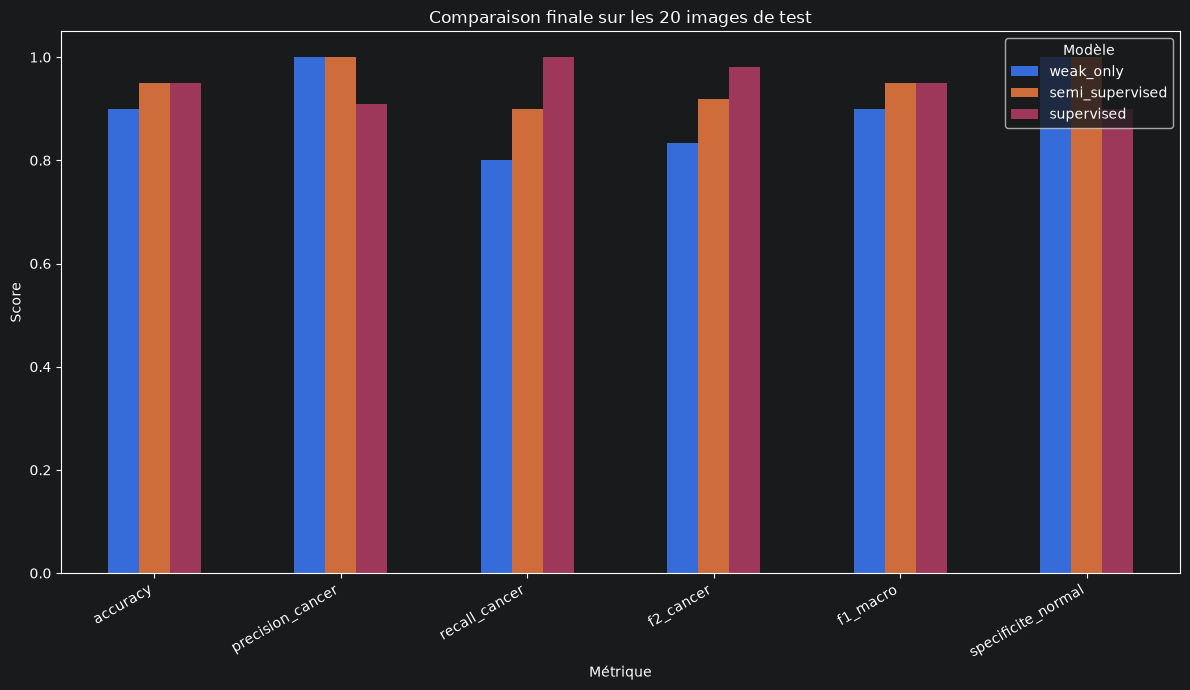

In [113]:
metriques_graphique_final = [
    "accuracy",
    "precision_cancer",
    "recall_cancer",
    "f2_cancer",
    "f1_macro",
    "specificite_normal",
]

comparaison_test_final[
    metriques_graphique_final
].T.plot(
    kind="bar",
    figsize=(12, 7),
)

plt.title(
    "Comparaison finale sur les 20 images de test"
)

plt.xlabel("Métrique")
plt.ylabel("Score")
plt.ylim(0.0, 1.05)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.legend(
    title="Modèle"
)

plt.tight_layout()
plt.show()

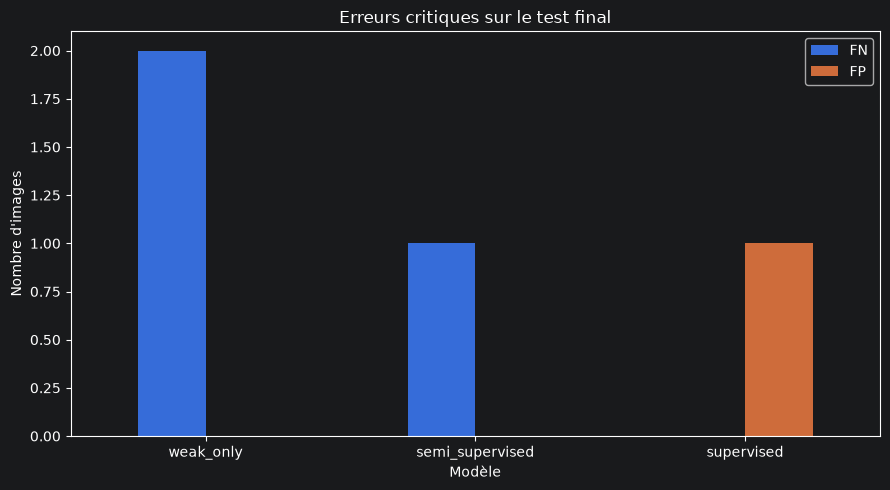

In [114]:
comparaison_test_final[
    [
        "FN",
        "FP",
    ]
].plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title(
    "Erreurs critiques sur le test final"
)

plt.xlabel("Modèle")
plt.ylabel("Nombre d'images")

plt.xticks(
    rotation=0,
)

plt.tight_layout()
plt.show()

In [115]:
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
)

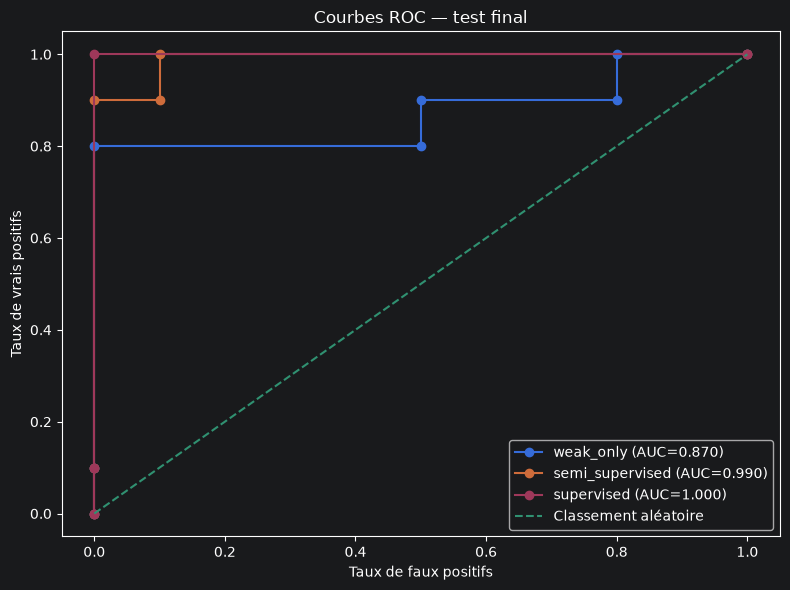

In [116]:
plt.figure(figsize=(8, 6))

for nom_modele, details in (
    details_test_par_modele.items()
):
    fpr, tpr, _ = roc_curve(
        details["y_true"],
        details[
            "y_probability_cancer"
        ],
    )

    score_auc = (
        comparaison_test_final.loc[
            nom_modele,
            "roc_auc",
        ]
    )

    plt.plot(
        fpr,
        tpr,
        marker="o",
        label=(
            f"{nom_modele} "
            f"(AUC={score_auc:.3f})"
        ),
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classement aléatoire",
)

plt.xlabel(
    "Taux de faux positifs"
)

plt.ylabel(
    "Taux de vrais positifs"
)

plt.title(
    "Courbes ROC — test final"
)

plt.legend()
plt.tight_layout()
plt.show()

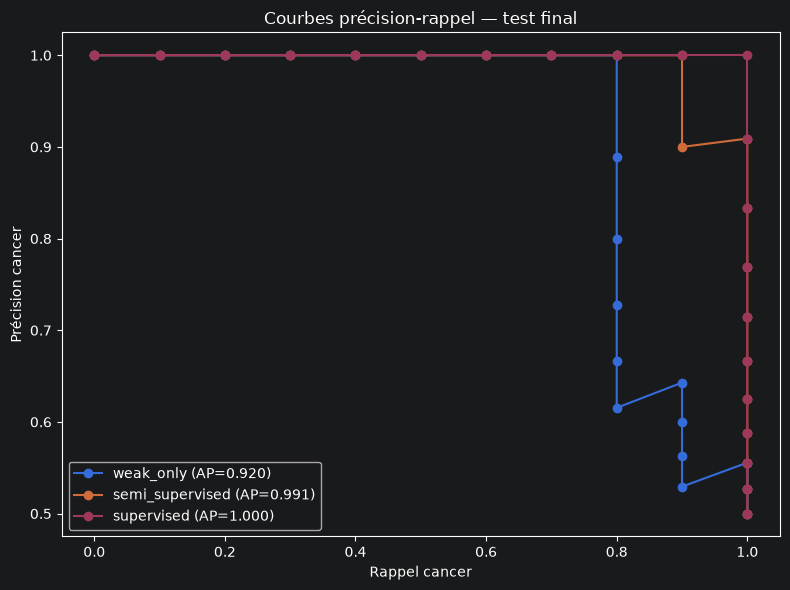

In [117]:
plt.figure(figsize=(8, 6))

for nom_modele, details in (
    details_test_par_modele.items()
):
    precision, recall, _ = (
        precision_recall_curve(
            details["y_true"],
            details[
                "y_probability_cancer"
            ],
        )
    )

    score_ap = (
        comparaison_test_final.loc[
            nom_modele,
            "average_precision",
        ]
    )

    plt.plot(
        recall,
        precision,
        marker="o",
        label=(
            f"{nom_modele} "
            f"(AP={score_ap:.3f})"
        ),
    )

plt.xlabel("Rappel cancer")
plt.ylabel("Précision cancer")

plt.title(
    "Courbes précision-rappel — test final"
)

plt.legend()
plt.tight_layout()
plt.show()

In [118]:
df_predictions_test = pd.DataFrame(
    {
        "image_path": (
            details_weak_test["paths"]
        ),
        "label_reel_id": (
            details_weak_test["y_true"]
        ),
        "label_reel": [
            LABEL_NAMES[int(label_id)]
            for label_id
            in details_weak_test["y_true"]
        ],
        "prediction_weak_only_id": (
            details_weak_test["y_pred"]
        ),
        "probabilite_cancer_weak_only": (
            details_weak_test[
                "y_probability_cancer"
            ]
        ),
        "prediction_semi_supervised_id": (
            details_semi_test["y_pred"]
        ),
        "probabilite_cancer_semi_supervised": (
            details_semi_test[
                "y_probability_cancer"
            ]
        ),
        "prediction_supervised_id": (
            details_supervised_test["y_pred"]
        ),
        "probabilite_cancer_supervised": (
            details_supervised_test[
                "y_probability_cancer"
            ]
        ),
    }
)

for colonne_prediction in [
    "prediction_weak_only_id",
    "prediction_semi_supervised_id",
    "prediction_supervised_id",
]:
    colonne_nom = colonne_prediction.replace(
        "_id",
        "",
    )

    df_predictions_test[
        colonne_nom
    ] = [
        LABEL_NAMES[int(label_id)]
        for label_id
        in df_predictions_test[
            colonne_prediction
        ]
    ]

display(
    df_predictions_test
)

,image_path,label_reel_id,label_reel,prediction_weak_only_id,probabilite_cancer_weak_only,prediction_semi_supervised_id,probabilite_cancer_semi_supervised,prediction_supervised_id,probabilite_cancer_supervised,prediction_weak_only,prediction_semi_supervised,prediction_supervised
0,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,1,cancer,0,0.231892,1,0.725386,1,0.605606,normal,cancer,cancer
1,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,1,cancer,1,0.803422,1,0.728338,1,0.935306,cancer,cancer,cancer
2,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,1,cancer,1,0.814657,1,0.854211,1,0.923473,cancer,cancer,cancer
3,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,1,cancer,1,0.870148,1,0.972720,1,0.977166,cancer,cancer,cancer
4,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,1,cancer,0,0.146613,0,0.222608,1,0.833969,normal,normal,cancer
5,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,1,cancer,1,0.973647,1,0.997232,1,0.920315,cancer,cancer,cancer
6,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,1,cancer,1,0.698199,1,0.536341,1,0.860926,cancer,cancer,cancer
7,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,1,cancer,1,0.983382,1,0.990708,1,0.970866,cancer,cancer,cancer
8,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,1,cancer,1,0.995118,1,0.999699,1,0.989385,cancer,cancer,cancer
9,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,1,cancer,1,0.778736,1,0.984605,1,0.912109,cancer,cancer,cancer


In [119]:
TEST_COMPARISON_PATH = (
    SEMI_SUPERVISED_DIR
    / "test_model_comparison.csv"
)

TEST_GAINS_PATH = (
    SEMI_SUPERVISED_DIR
    / "test_semi_vs_supervised_gains.csv"
)

TEST_PREDICTIONS_PATH = (
    PREDICTIONS_DIR
    / "test_predictions_all_models.csv"
)

comparaison_test_final.to_csv(
    TEST_COMPARISON_PATH
)

df_gains_test_final.to_csv(
    TEST_GAINS_PATH
)

df_predictions_test.to_csv(
    TEST_PREDICTIONS_PATH,
    index=False,
)

print(
    "Comparaison finale :",
    TEST_COMPARISON_PATH,
)

print(
    "Gains semi-supervisés :",
    TEST_GAINS_PATH,
)

print(
    "Prédictions individuelles :",
    TEST_PREDICTIONS_PATH,
)

Comparaison finale : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/test_model_comparison.csv
Gains semi-supervisés : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/test_semi_vs_supervised_gains.csv
Prédictions individuelles : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/semi_supervised/predictions/test_predictions_all_models.csv


In [120]:
modele_meilleur_f2 = (
    comparaison_test_final[
        "f2_cancer"
    ]
    .idxmax()
)

modele_meilleur_recall = (
    comparaison_test_final[
        "recall_cancer"
    ]
    .idxmax()
)

modele_moins_fn = (
    comparaison_test_final[
        "FN"
    ]
    .idxmin()
)

gain_f2 = float(
    df_gains_test_final.loc[
        "f2_cancer",
        "gain_semi_vs_supervised",
    ]
)

gain_recall = float(
    df_gains_test_final.loc[
        "recall_cancer",
        "gain_semi_vs_supervised",
    ]
)

print(
    "Meilleur F2 cancer :",
    modele_meilleur_f2,
)

print(
    "Meilleur rappel cancer :",
    modele_meilleur_recall,
)

print(
    "Plus faible nombre de faux négatifs :",
    modele_moins_fn,
)

print(
    "Gain F2 semi-supervisé vs supervisé :",
    round(gain_f2, 4),
)

print(
    "Gain recall semi-supervisé vs supervisé :",
    round(gain_recall, 4),
)

Meilleur F2 cancer : supervised
Meilleur rappel cancer : supervised
Plus faible nombre de faux négatifs : supervised
Gain F2 semi-supervisé vs supervisé : -0.062
Gain recall semi-supervisé vs supervisé : -0.1


## 19. Definition of Done — apprentissage semi-supervisé

L'étape est considérée comme terminée lorsque les conditions suivantes
sont satisfaites :

- [x] un jeu expert équilibré a été séparé en train, validation et test ;
- [x] le jeu de test n'a participé ni au clustering, ni à la création
  des labels faibles, ni à l'entraînement ;
- [x] les 1 406 images non annotées ont reçu un label faible accompagné
  d'un indicateur de confiance ;
- [x] un CNN ResNet-18 a été entraîné sur les labels faibles ;
- [x] le même CNN a ensuite été affiné sur les labels experts ;
- [x] un CNN supervisé de référence a été entraîné uniquement sur les
  labels experts ;
- [x] les modèles ont été sélectionnés uniquement avec la validation ;
- [x] les trois modèles ont été évalués sur le même test final ;
- [x] le rappel cancer, le F2-score, la précision, le F1-score, la
  balanced accuracy, la ROC-AUC et l'Average Precision ont été calculés ;
- [x] les faux négatifs ont été explicitement quantifiés ;
- [x] les matrices de confusion et les courbes de performance ont été
  produites ;
- [x] les checkpoints, historiques, prédictions et tableaux comparatifs
  ont été sauvegardés.

## Limites

Les résultats ne constituent pas une validation clinique.

Le jeu expert ne contient que 100 images et le test final seulement
20 images. Une erreur sur le test modifie donc l'accuracy de cinq points
de pourcentage.

La séparation a été réalisée au niveau des images. En l'absence
d'identifiant patient exploitable, il n'est pas possible de confirmer
une séparation stricte au niveau des patients.

La qualité des labels faibles dépend du clustering et de la
correspondance entre clusters et classes. Leur score de confiance est
une heuristique géométrique et non une probabilité médicale.

Une validation externe, multi-centrique et réalisée avec des données
annotées par plusieurs radiologues serait indispensable avant toute
utilisation clinique.